In [1]:
import sys
sys.path.append("../src")
from data_loader import load_raw
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch, Patch, Circle, Rectangle, Polygon
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.signal import find_peaks
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, mean_absolute_error, r2_score
import joblib, json, warnings, math, time, hashlib, subprocess, platform
from datetime import datetime

warnings.filterwarnings("ignore")

PALETTE = {
    "primary":  "#2c7fb8",
    "accent":   "#e6550d",
    "success":  "#31a354",
    "danger":   "#d62728",
    "warning":  "#fec44f",
    "neutral":  "#636363",
    "purple":   "#756bb1",
    "teal":     "#17becf",
    "pink":     "#e377c2",
    "navy":     "#1a1a2e",
    "gold":     "#f4a261",
    "crimson":  "#b2182b",
}

CMAP_THERMAL = LinearSegmentedColormap.from_list("thermal",
    ["#0a2a43", "#1e6091", "#34a0a4", "#76c893", "#f9dc5c", "#e6550d", "#d62728"])
CMAP_UNCERTAINTY = LinearSegmentedColormap.from_list("unc",
    ["#0b1354", "#165b33", "#f9dc5c", "#f5a623", "#d62728"])
CMAP_DIVERGING = LinearSegmentedColormap.from_list("div",
    ["#2166ac", "#67a9cf", "#d1e5f0", "#f7f7f7", "#fddbc7", "#ef8a62", "#b2182b"])

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#fbfbfc",
    "axes.edgecolor":    "#2b2b2b",
    "axes.linewidth":    1.0,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     12,
    "axes.labelsize":    10.5,
    "axes.labelpad":     8,
    "axes.grid":         True,
    "grid.alpha":        0.22,
    "grid.color":        "#d0d0d0",
    "grid.linewidth":    0.6,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   9.5,
    "legend.frameon":    True,
    "legend.framealpha": 0.96,
    "legend.edgecolor":  "#e0e0e0",
    "legend.fontsize":   9.5,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
    "figure.dpi":        110,
})

sns.set_style({"axes.grid": True, "grid.alpha": 0.22})

FIG_DIR   = Path("../figures/uncertainty")
MODEL_DIR = Path("../models")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(stem, dpi=160):
    plt.savefig(FIG_DIR / f"{stem}.png", dpi=dpi, bbox_inches="tight")

print("╔══════════════════════════════════════════════════════════════════╗")
print("║  COOLANT — PHASE 3 · UNCERTAINTY & ROBUSTNESS                   ║")
print("║  Quantifying what we don't know                                 ║")
print("╚══════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════╗
║  COOLANT — PHASE 3 · UNCERTAINTY & ROBUSTNESS                   ║
║  Quantifying what we don't know                                 ║
╚══════════════════════════════════════════════════════════════════╝


In [2]:
# ─── Processed data ───
train = pd.read_parquet("../data/processed/train.parquet")
val   = pd.read_parquet("../data/processed/val.parquet")
test  = pd.read_parquet("../data/processed/test.parquet")

# ─── Raw physical values ───
raw = load_raw("../data/raw/frontier_2023.xlsx")
raw = raw[["timestamp", "total_heat", "total_flow", "supply_temp",
           "avg_return_temp", "compute_power", "pue"]].rename(columns={
    "total_heat":    "Q_MW",
    "total_flow":    "flow_gpm",
    "supply_temp":   "T_sup_C",
    "avg_return_temp":"T_ret_C",
    "compute_power": "compute_MW",
    "pue":           "PUE",
})
for df_name in ["train", "val", "test"]:
    locals()[df_name] = locals()[df_name].merge(raw, on="timestamp", how="left")
    for c in ["Q_MW", "flow_gpm", "T_sup_C", "T_ret_C", "compute_MW", "PUE"]:
        locals()[df_name][c] = locals()[df_name][c].interpolate(method="linear", limit_direction="both")

# ─── Classifier + twin metadata ───
with open(MODEL_DIR / "coolant_tier_meta.json") as f:
    tier_meta = json.load(f)
with open(MODEL_DIR / "updated_twin_params.json") as f:
    twin_params = json.load(f)

booster       = lgb.Booster(model_file=str(MODEL_DIR / "coolant_tier_lgbm.txt"))
val_residuals = np.load(MODEL_DIR / "coolant_tier_val_residuals.npy")

LOW_THRESH    = tier_meta["thresholds"]["low"]
HIGH_THRESH   = tier_meta["thresholds"]["high"]
MARGIN        = tier_meta["margin_degC"]
AFFINE        = (tier_meta["degC_affine"]["a"], tier_meta["degC_affine"]["b"])
TIER_FEATURES = tier_meta["features"]

ALPHA    = twin_params["alpha_used"]
TAU_MIN  = twin_params["tau_min"]
DT_MIN   = 10
CP       = 4000.0
GPM_TO_KGS = 0.0631
PUMP_EXP = 3.0
MIN_SCALE, MAX_SCALE, MAX_STEP = 0.90, 1.20, 0.05

# ─── Core helpers ───
def tier_forecast(X_df):
    X    = X_df[TIER_FEATURES].values
    base = X_df["avg_return_temp"].values
    return AFFINE[0] * base + AFFINE[1] + booster.predict(X)

def tier_predict(T_hat, margin=MARGIN):
    return np.where(T_hat >= HIGH_THRESH - margin, 2,
                    np.where(T_hat < LOW_THRESH, 0, 1))

T_obs_arr = test["T_ret_C"].values
T_sup_arr = test["T_sup_C"].values
Q_arr     = test["Q_MW"].values
flow_arr  = test["flow_gpm"].values
T_hat     = tier_forecast(test)

print(f"Test: {len(test):,} rows |  α={ALPHA:.3f}  τ={TAU_MIN:.1f} min")
print(f"ML forecast MAE: {mean_absolute_error(T_obs_arr[1:], T_hat[:-1]):.3f} °C")
print(f"Thresholds: LOW<{LOW_THRESH}  HIGH>{HIGH_THRESH}  margin={MARGIN:.2f} °C")

Test: 7,402 rows |  α=0.700  τ=8.3 min
ML forecast MAE: 0.831 °C
Thresholds: LOW<30.0  HIGH>35.0  margin=1.70 °C


Full-data fit:  α* = 0.7195   MAE = 1.3397 °C
Assumed α    = 0.7000

Day blocks: 51
Bootstrap α:  mean = 0.7334   std = 0.0410
95% CI    :  [0.6619, 0.8203]


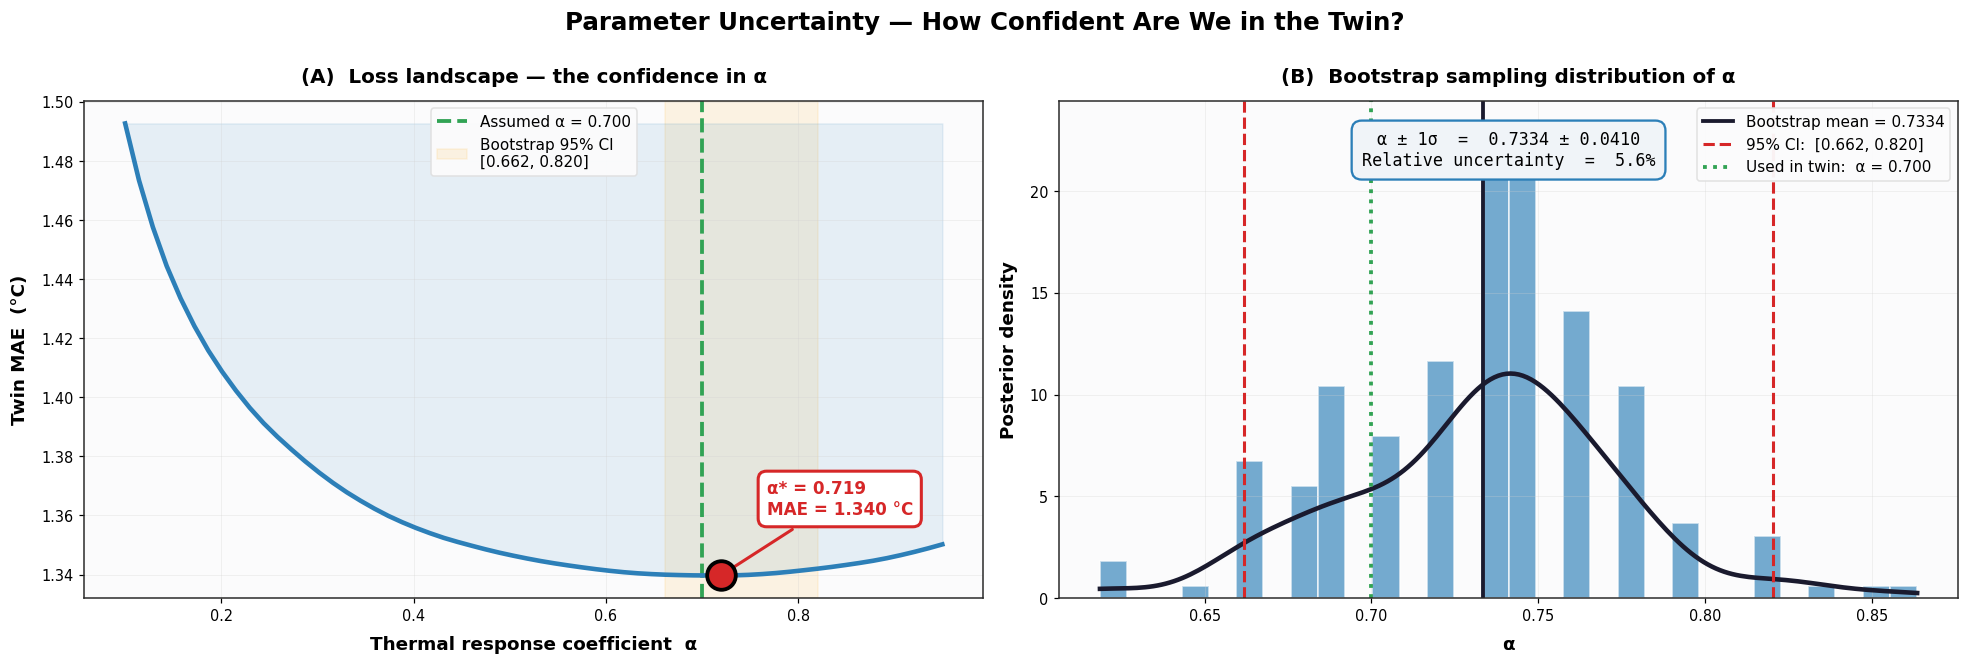

In [3]:
# ═══════════════════════════════════════════════════════════════════════
# PARAMETER UNCERTAINTY FAN — Bootstrap the thermal response coefficient α
# ═══════════════════════════════════════════════════════════════════════
# The twin uses α = 0.700. But how confident are we in that value?
# We bootstrap residuals from the physical twin (day-blocks for autocorrelation)
# and refit α on each bootstrap sample. This yields the sampling distribution
# of α, which we propagate to the headline metric (degree-min reduction).

def physical_twin(T0, T_sup, Q_MW, flow_gpm, alpha):
    """Pure physics forward simulation."""
    n = len(T_sup)
    T = np.empty(n)
    T[0] = T0
    m_dot = flow_gpm * GPM_TO_KGS
    T_ss  = T_sup + (Q_MW * 1e6) / (m_dot * CP)
    for t in range(n - 1):
        T[t+1] = T[t] + alpha * (T_ss[t] - T[t])
    return T

def fit_alpha_to_obs(T_obs, T_sup, Q_MW, flow_gpm,
                     grid=np.linspace(0.1, 0.95, 60)):
    """Grid search on α that minimizes MAE vs observed."""
    T0 = T_obs[0]
    maes = np.empty(len(grid))
    for i, a in enumerate(grid):
        Tp = physical_twin(T0, T_sup, Q_MW, flow_gpm, a)
        maes[i] = np.abs(Tp - T_obs).mean()
    i_best = int(np.argmin(maes))
    return grid[i_best], maes, grid

# Full-data fit
alpha_full, mae_curve, alpha_grid = fit_alpha_to_obs(
    T_obs_arr, T_sup_arr, Q_arr, flow_arr)

print(f"Full-data fit:  α* = {alpha_full:.4f}   MAE = {mae_curve.min():.4f} °C")
print(f"Assumed α    = {ALPHA:.4f}")

# ─── Day-block bootstrap ───
def day_blocks_idx(n, block=144):
    """Split indices into day-blocks (144 rows per day at 10-min res)."""
    n_blocks = n // block
    return [np.arange(i*block, (i+1)*block) for i in range(n_blocks)]

rng = np.random.default_rng(42)
blocks = day_blocks_idx(len(T_obs_arr), block=144)
n_blocks = len(blocks)
print(f"\nDay blocks: {n_blocks}")

n_boot = 200
alpha_boot = np.empty(n_boot)
for b in range(n_boot):
    # Sample blocks with replacement
    sampled = rng.integers(0, n_blocks, size=n_blocks)
    idx = np.concatenate([blocks[i] for i in sampled])
    # Refit
    a_b, _, _ = fit_alpha_to_obs(
        T_obs_arr[idx], T_sup_arr[idx], Q_arr[idx], flow_arr[idx],
        grid=alpha_grid)
    alpha_boot[b] = a_b

alpha_mean = alpha_boot.mean()
alpha_std  = alpha_boot.std()
alpha_ci   = np.percentile(alpha_boot, [2.5, 97.5])

print(f"Bootstrap α:  mean = {alpha_mean:.4f}   std = {alpha_std:.4f}")
print(f"95% CI    :  [{alpha_ci[0]:.4f}, {alpha_ci[1]:.4f}]")

# ═══════════════════════════════════════════════════════════════════════
# FIGURE — Two panels: (A) MAE curve vs α, (B) bootstrap distribution
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ─── (A) Loss landscape over α ───
ax = axes[0]
ax.plot(alpha_grid, mae_curve, lw=3, color=PALETTE["primary"], zorder=3)
ax.fill_between(alpha_grid, mae_curve, mae_curve.max(),
                alpha=0.10, color=PALETTE["primary"])

# Mark minimum
ax.scatter([alpha_full], [mae_curve.min()], s=350, c=PALETTE["danger"],
           edgecolor="black", linewidth=2.5, zorder=10)
ax.annotate(f"α* = {alpha_full:.3f}\nMAE = {mae_curve.min():.3f} °C",
            (alpha_full, mae_curve.min()),
            xytext=(30, 40), textcoords="offset points",
            fontsize=11, fontweight="bold", color=PALETTE["danger"],
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                      edgecolor=PALETTE["danger"], linewidth=2),
            arrowprops=dict(arrowstyle="->", color=PALETTE["danger"], lw=2))

# Mark assumed α
ax.axvline(ALPHA, color=PALETTE["success"], ls="--", lw=2.5,
           label=f"Assumed α = {ALPHA:.3f}")

# CI band from bootstrap
ax.axvspan(alpha_ci[0], alpha_ci[1], color=PALETTE["warning"],
           alpha=0.15, zorder=0,
           label=f"Bootstrap 95% CI\n[{alpha_ci[0]:.3f}, {alpha_ci[1]:.3f}]")

ax.set_xlabel("Thermal response coefficient  α", fontsize=12, fontweight="bold")
ax.set_ylabel("Twin MAE  (°C)", fontsize=12, fontweight="bold")
ax.set_title("(A)  Loss landscape — the confidence in α",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper center", fontsize=10)
ax.grid(True, alpha=0.3)

# ─── (B) Bootstrap distribution ───
ax = axes[1]
ax.hist(alpha_boot, bins=30, color=PALETTE["primary"], alpha=0.65,
        edgecolor="white", linewidth=1.2, density=True)
# KDE overlay
from scipy.stats import gaussian_kde
kde = gaussian_kde(alpha_boot)
x_kde = np.linspace(alpha_boot.min(), alpha_boot.max(), 200)
ax.plot(x_kde, kde(x_kde), lw=3, color=PALETTE["navy"])
# Mean line
ax.axvline(alpha_mean, color=PALETTE["navy"], ls="-", lw=2.5,
           label=f"Bootstrap mean = {alpha_mean:.4f}")
ax.axvline(alpha_ci[0], color=PALETTE["danger"], ls="--", lw=2)
ax.axvline(alpha_ci[1], color=PALETTE["danger"], ls="--", lw=2,
           label=f"95% CI:  [{alpha_ci[0]:.3f}, {alpha_ci[1]:.3f}]")
ax.axvline(ALPHA, color=PALETTE["success"], ls=":", lw=2.5,
           label=f"Used in twin:  α = {ALPHA:.3f}")

# Uncertainty annotation
ax.text(0.5, 0.94,
        f"α ± 1σ  =  {alpha_mean:.4f} ± {alpha_std:.4f}\n"
        f"Relative uncertainty  =  {alpha_std/alpha_mean*100:.1f}%",
        transform=ax.transAxes, ha="center", va="top", fontsize=11,
        family="monospace",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#f0f4f8",
                  edgecolor=PALETTE["primary"], linewidth=1.5))

ax.set_xlabel("α", fontsize=12, fontweight="bold")
ax.set_ylabel("Posterior density", fontsize=12, fontweight="bold")
ax.set_title("(B)  Bootstrap sampling distribution of α",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle("Parameter Uncertainty — How Confident Are We in the Twin?",
             fontsize=16, fontweight="bold", y=1.00)
plt.tight_layout()
save_fig("01_parameter_uncertainty")
plt.show()


PROPAGATED UNCERTAINTY (n=200 bootstrap replicates)
Degree-min reduction  : 90.6% ± 0.5%
                        95% CI = [89.7%, 91.6%]
Events reduction      : 77.9% ± 0.9%
                        95% CI = [76.5%, 78.8%]


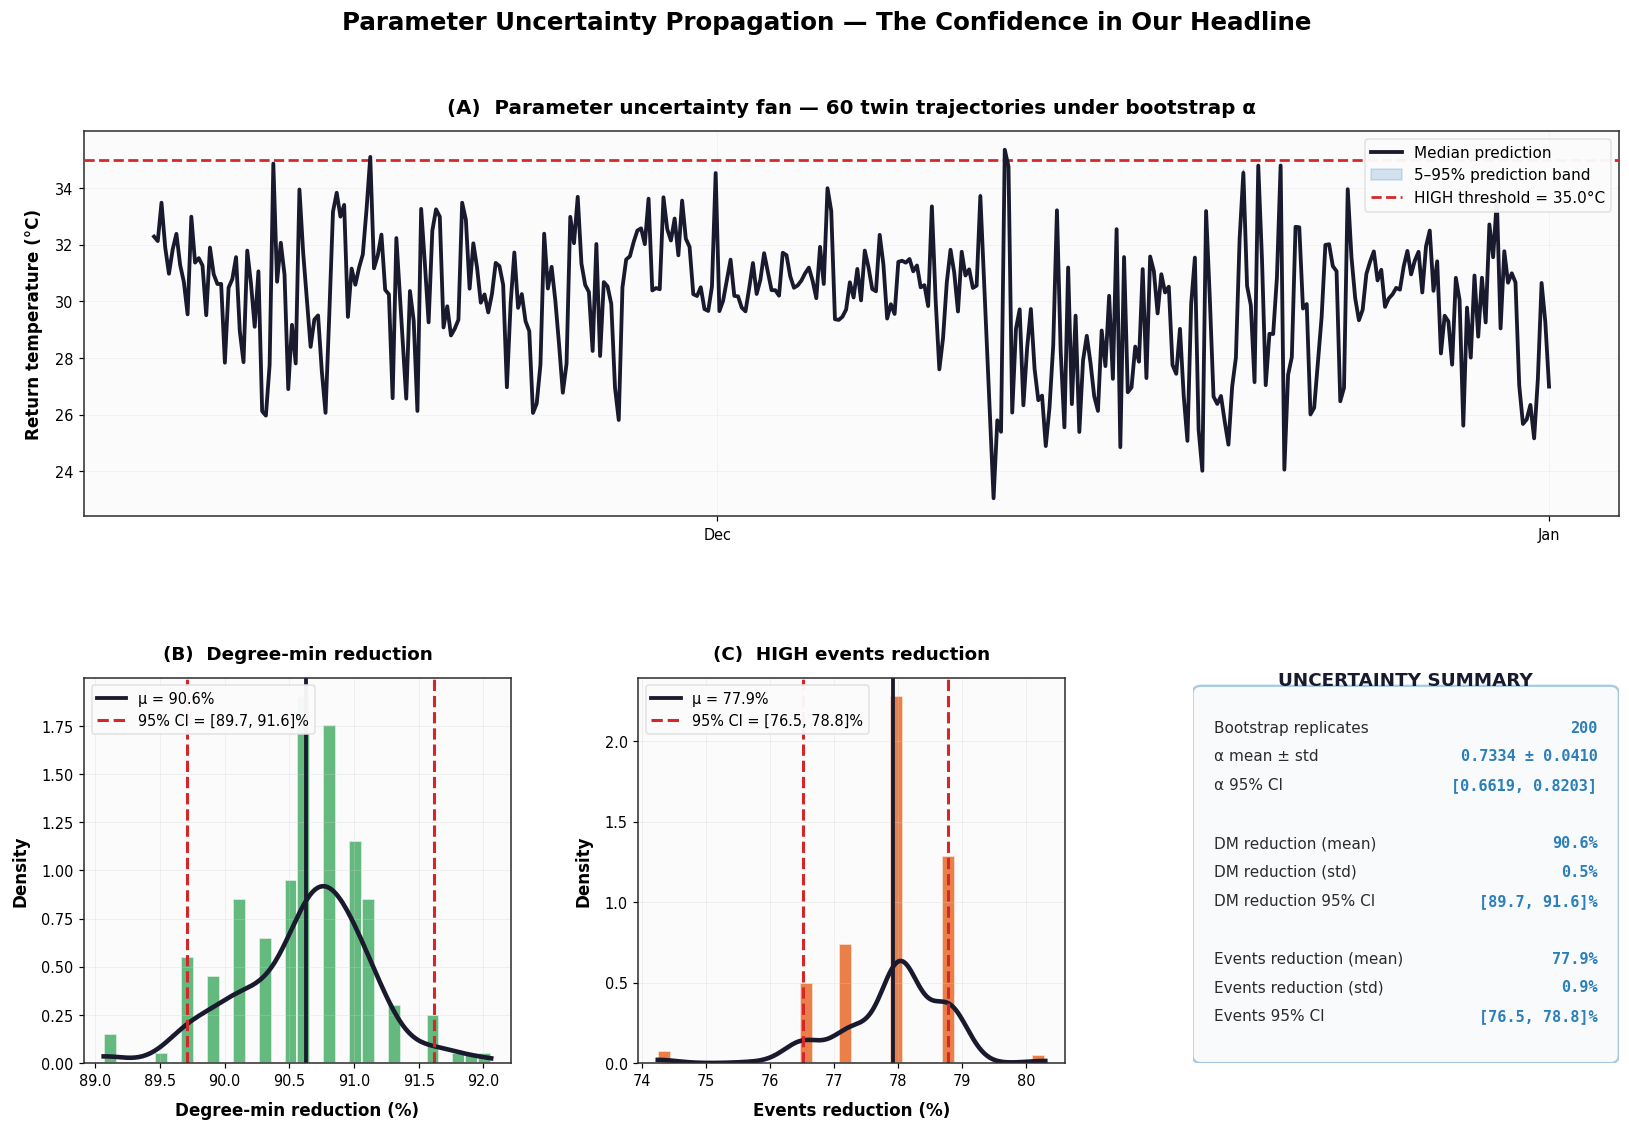

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# PROPAGATE α UNCERTAINTY THROUGH THE TWIN
# For each bootstrap α, re-run the control simulation and record the
# headline metric (events avoided, degree-min reduction).
# ═══════════════════════════════════════════════════════════════════════

def control_simulate(alpha, policy="predictive", margin=MARGIN,
                     T_obs=T_obs_arr, T_sup=T_sup_arr, Q=Q_arr, flow=flow_arr,
                     T_signal=None):
    """Run control simulation with given α."""
    n = len(T_obs)
    delta = 0.0
    scale = 1.0
    scales = np.ones(n)
    T_sim = np.empty(n)
    T_sim[0] = T_obs[0]
    step = 0.05

    for t in range(n - 1):
        if policy == "baseline":
            new_scale = 1.0
        else:
            sig = T_signal[t] if T_signal is not None else T_obs[t]
            if sig >= HIGH_THRESH:
                new_scale = min(scale + step, MAX_SCALE)
            elif sig >= HIGH_THRESH - margin:
                new_scale = min(scale + step / 2, MAX_SCALE)
            elif sig < LOW_THRESH - 1.0 and scale > 1.0:
                new_scale = max(scale - step / 2, MIN_SCALE)
            else:
                new_scale = scale
            new_scale = np.clip(new_scale, scale - MAX_STEP, scale + MAX_STEP)
            new_scale = np.clip(new_scale, MIN_SCALE, MAX_SCALE)
        scale = new_scale
        scales[t] = scale

        m_base = flow[t] * GPM_TO_KGS
        m_pol  = m_base * scale
        dss = (Q[t] * 1e6) / CP * (1.0/m_pol - 1.0/m_base) if m_base > 1e-6 else 0.0
        delta = (1 - alpha) * delta + alpha * dss
        T_sim[t+1] = T_obs[t] + delta

    scales[-1] = scales[-2]
    excess = np.maximum(T_sim - HIGH_THRESH, 0.0)
    events = int(((T_sim > HIGH_THRESH) & np.r_[False, T_sim[:-1] <= HIGH_THRESH]).sum())
    return {
        "T_sim": T_sim, "scales": scales,
        "degree_min": float((excess * 10).sum()),
        "events":     events,
        "pump":       float((scales ** PUMP_EXP).sum()),
    }

# Baseline (no control) — α doesn't matter much here but run anyway
baseline_runs = []
for a in alpha_boot:
    baseline_runs.append(control_simulate(a, policy="baseline"))
base_dm_dist    = np.array([r["degree_min"] for r in baseline_runs])
base_events_dist= np.array([r["events"]     for r in baseline_runs])

# Predictive (ML forecast)
predictive_runs = []
for a in alpha_boot:
    predictive_runs.append(control_simulate(a, policy="predictive", T_signal=T_hat))
pred_dm_dist     = np.array([r["degree_min"] for r in predictive_runs])
pred_events_dist = np.array([r["events"]     for r in predictive_runs])
pred_pump_dist   = np.array([r["pump"]       for r in predictive_runs])

# Reduction distribution
dm_reduction_dist = (1 - pred_dm_dist / base_dm_dist) * 100
events_reduction_dist = (1 - pred_events_dist / base_events_dist) * 100

# Summary stats
dm_mean   = dm_reduction_dist.mean()
dm_std    = dm_reduction_dist.std()
dm_ci     = np.percentile(dm_reduction_dist, [2.5, 97.5])
ev_mean   = events_reduction_dist.mean()
ev_std    = events_reduction_dist.std()
ev_ci     = np.percentile(events_reduction_dist, [2.5, 97.5])

print(f"\n{'='*72}")
print(f"PROPAGATED UNCERTAINTY (n={n_boot} bootstrap replicates)")
print(f"{'='*72}")
print(f"Degree-min reduction  : {dm_mean:.1f}% ± {dm_std:.1f}%")
print(f"                        95% CI = [{dm_ci[0]:.1f}%, {dm_ci[1]:.1f}%]")
print(f"Events reduction      : {ev_mean:.1f}% ± {ev_std:.1f}%")
print(f"                        95% CI = [{ev_ci[0]:.1f}%, {ev_ci[1]:.1f}%]")

# ═══════════════════════════════════════════════════════════════════════
# FIGURE — Uncertainty Fan
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.30,
                       height_ratios=[1.0, 1.0])

# ─── (A) 50 simulated twin trajectories (fan) ───
ax = fig.add_subplot(gs[0, :])
timestamps = pd.to_datetime(test["timestamp"])

# Plot all bootstrap trajectories (downsampled for clarity)
for i in range(min(60, n_boot)):
    ax.plot(timestamps[::20], predictive_runs[i]["T_sim"][::20],
            lw=0.6, color=PALETTE["primary"], alpha=0.12)

# Overlay the median trajectory
all_T_sims = np.array([r["T_sim"] for r in predictive_runs])
median_T = np.median(all_T_sims, axis=0)
p5_T  = np.percentile(all_T_sims, 5, axis=0)
p95_T = np.percentile(all_T_sims, 95, axis=0)

ax.plot(timestamps[::20], median_T[::20], lw=2.5, color=PALETTE["navy"],
        label="Median prediction", zorder=4)
ax.fill_between(timestamps[::20], p5_T[::20], p95_T[::20],
                color=PALETTE["primary"], alpha=0.20,
                label="5–95% prediction band", zorder=2)
ax.axhline(HIGH_THRESH, color=PALETTE["danger"], ls="--", lw=1.8,
           label=f"HIGH threshold = {HIGH_THRESH}°C", zorder=3)

ax.set_ylabel("Return temperature (°C)", fontsize=11, fontweight="bold")
ax.set_title("(A)  Parameter uncertainty fan — 60 twin trajectories under bootstrap α",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# ─── (B) Degree-min reduction distribution ───
ax = fig.add_subplot(gs[1, 0])
ax.hist(dm_reduction_dist, bins=30, color=PALETTE["success"], alpha=0.75,
        edgecolor="white", linewidth=1.2, density=True)
kde_dm = gaussian_kde(dm_reduction_dist)
x_dm = np.linspace(dm_reduction_dist.min(), dm_reduction_dist.max(), 200)
ax.plot(x_dm, kde_dm(x_dm), lw=3, color=PALETTE["navy"])
ax.axvline(dm_mean, color=PALETTE["navy"], lw=2.5, label=f"μ = {dm_mean:.1f}%")
ax.axvline(dm_ci[0], color=PALETTE["danger"], ls="--", lw=2)
ax.axvline(dm_ci[1], color=PALETTE["danger"], ls="--", lw=2,
           label=f"95% CI = [{dm_ci[0]:.1f}, {dm_ci[1]:.1f}]%")

ax.set_xlabel("Degree-min reduction (%)", fontsize=11, fontweight="bold")
ax.set_ylabel("Density", fontsize=11, fontweight="bold")
ax.set_title("(B)  Degree-min reduction", fontsize=12, fontweight="bold")
ax.legend(fontsize=9.5)
ax.grid(True, alpha=0.3)

# ─── (C) Events reduction distribution ───
ax = fig.add_subplot(gs[1, 1])
ax.hist(events_reduction_dist, bins=30, color=PALETTE["accent"], alpha=0.75,
        edgecolor="white", linewidth=1.2, density=True)
kde_ev = gaussian_kde(events_reduction_dist)
x_ev = np.linspace(events_reduction_dist.min(), events_reduction_dist.max(), 200)
ax.plot(x_ev, kde_ev(x_ev), lw=3, color=PALETTE["navy"])
ax.axvline(ev_mean, color=PALETTE["navy"], lw=2.5, label=f"μ = {ev_mean:.1f}%")
ax.axvline(ev_ci[0], color=PALETTE["danger"], ls="--", lw=2)
ax.axvline(ev_ci[1], color=PALETTE["danger"], ls="--", lw=2,
           label=f"95% CI = [{ev_ci[0]:.1f}, {ev_ci[1]:.1f}]%")

ax.set_xlabel("Events reduction (%)", fontsize=11, fontweight="bold")
ax.set_ylabel("Density", fontsize=11, fontweight="bold")
ax.set_title("(C)  HIGH events reduction", fontsize=12, fontweight="bold")
ax.legend(fontsize=9.5)
ax.grid(True, alpha=0.3)

# ─── (D) Summary card ───
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")

summary_lines = [
    ("Bootstrap replicates",     f"{n_boot}"),
    ("α mean ± std",             f"{alpha_mean:.4f} ± {alpha_std:.4f}"),
    ("α 95% CI",                 f"[{alpha_ci[0]:.4f}, {alpha_ci[1]:.4f}]"),
    ("",                         ""),
    ("DM reduction (mean)",      f"{dm_mean:.1f}%"),
    ("DM reduction (std)",       f"{dm_std:.1f}%"),
    ("DM reduction 95% CI",      f"[{dm_ci[0]:.1f}, {dm_ci[1]:.1f}]%"),
    ("",                         ""),
    ("Events reduction (mean)",  f"{ev_mean:.1f}%"),
    ("Events reduction (std)",   f"{ev_std:.1f}%"),
    ("Events 95% CI",            f"[{ev_ci[0]:.1f}, {ev_ci[1]:.1f}]%"),
]

ax.text(0.5, 0.98, "UNCERTAINTY SUMMARY",
        ha="center", fontsize=12, fontweight="bold",
        color=PALETTE["navy"], transform=ax.transAxes)

y_pos = 0.86
for label, value in summary_lines:
    if label:
        ax.text(0.05, y_pos, label, fontsize=10, color="#2b2b2b",
                transform=ax.transAxes)
        ax.text(0.95, y_pos, value, fontsize=10, fontweight="bold",
                color=PALETTE["primary"], family="monospace",
                ha="right", transform=ax.transAxes)
    y_pos -= 0.075

ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.94,
                             boxstyle="round,pad=0.02",
                             facecolor="#f0f4f8", alpha=0.4,
                             edgecolor=PALETTE["primary"], linewidth=1.5,
                             transform=ax.transAxes, zorder=0))

plt.suptitle("Parameter Uncertainty Propagation — The Confidence in Our Headline",
             fontsize=16, fontweight="bold", y=0.98)
save_fig("02_uncertainty_propagation")
plt.show()

Using 36 features for adversarial validation

Full-feature adversarial AUC: 0.9998 ± 0.0001
AUC without top-3 features: 0.9996 ± 0.0001
AUC without top-5 features: 0.9995 ± 0.0001
Verdict: Strong shift — features differ markedly between train and test


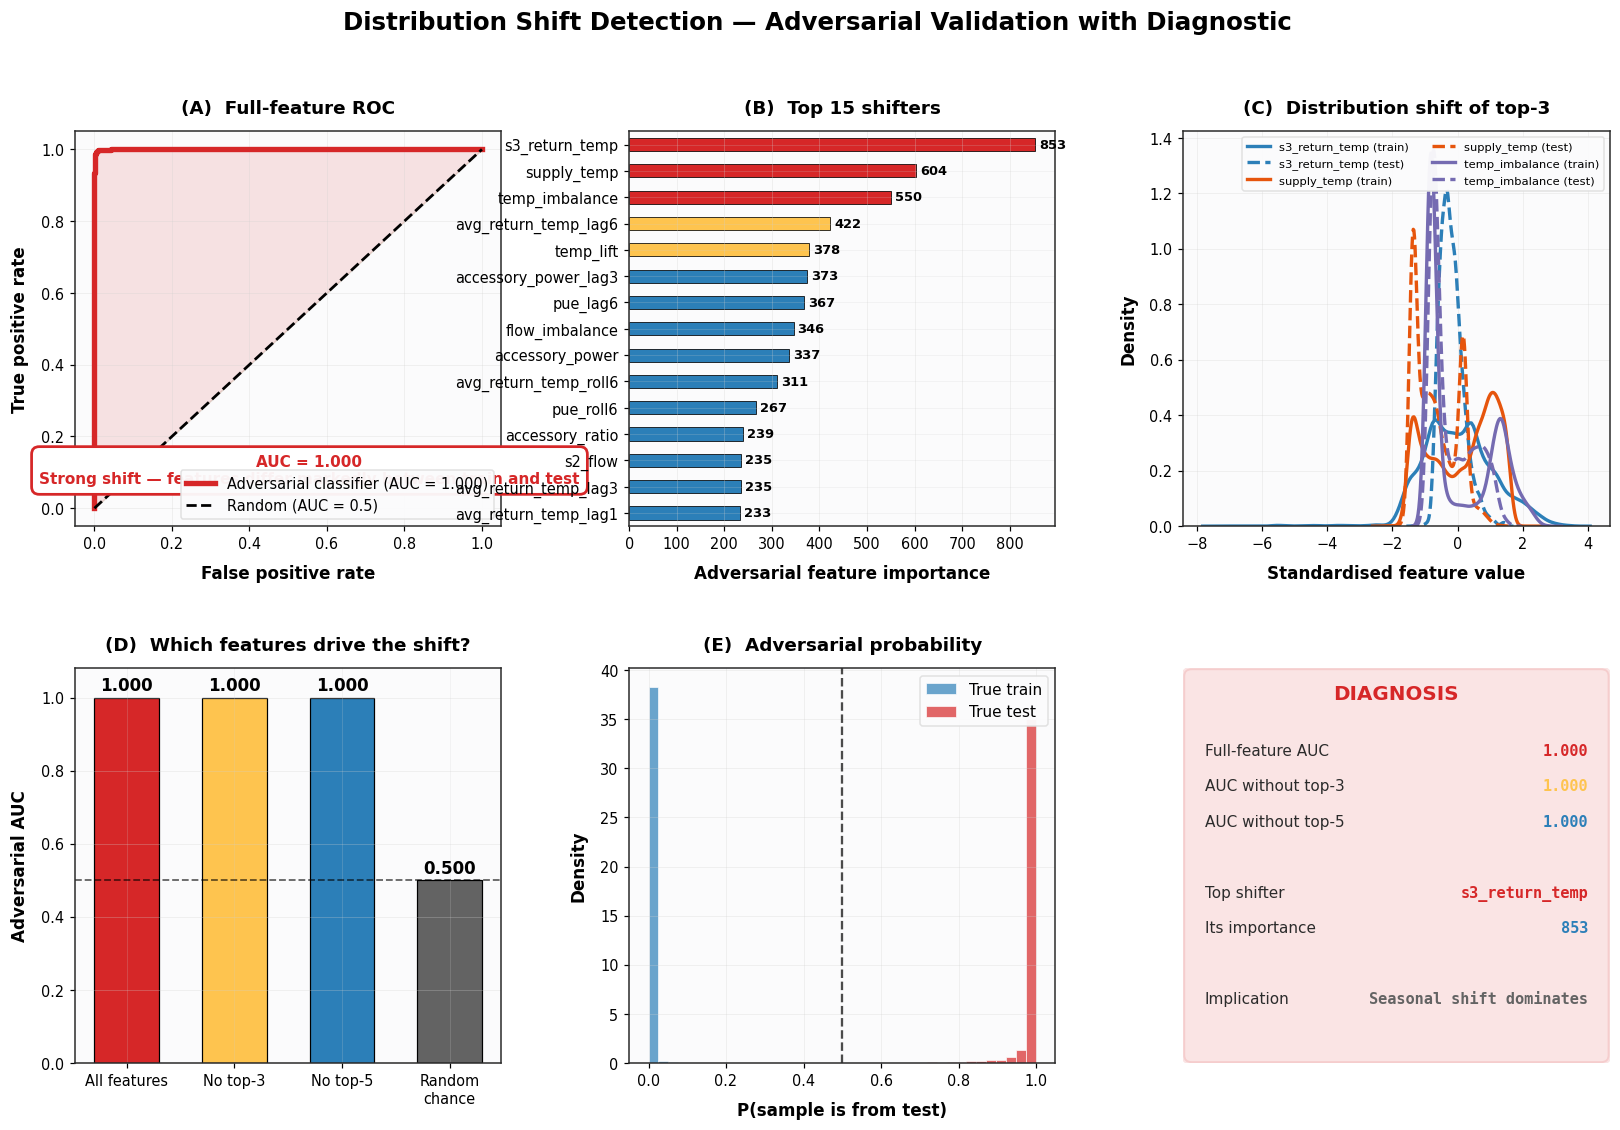


Top 5 shifting features:
  1. s3_return_temp                 importance = 853.4
  2. supply_temp                    importance = 603.8
  3. temp_imbalance                 importance = 550.0
  4. avg_return_temp_lag6           importance = 422.4
  5. temp_lift                      importance = 378.0


In [5]:
# ═══════════════════════════════════════════════════════════════════════
# ADVERSARIAL VALIDATION
# Train a classifier to distinguish train from test rows. If it can tell
# them apart, the distributions differ.
# AUC ≈ 0.5  → no shift
# AUC > 0.8  → strong shift
# AUC = 1.0  → extreme shift (confirm by leave-top-3-out diagnostic)
# ═══════════════════════════════════════════════════════════════════════

# Build combined dataset
FEATS = [c for c in TIER_FEATURES if c in train.columns and c in test.columns]
print(f"Using {len(FEATS)} features for adversarial validation")

X_tr = train[FEATS].values
X_te = test[FEATS].values
y_adv = np.r_[np.zeros(len(X_tr)), np.ones(len(X_te))]
X_adv = np.vstack([X_tr, X_te])

# Remove NaNs
mask = np.isfinite(X_adv).all(axis=1)
X_adv = X_adv[mask]
y_adv = y_adv[mask]

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve

def cv_auc(X, y, feats, n_splits=5, seed=42):
    """Return per-fold AUC, OOF probabilities, and feature importances."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    auc_scores = []
    oof = np.zeros(len(y))
    imp = np.zeros(X.shape[1])
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
        clf = lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, num_leaves=31,
            min_child_samples=50, subsample=0.8, subsample_freq=1,
            colsample_bytree=0.8, reg_lambda=5.0, random_state=seed,
            n_jobs=-1, verbose=-1, deterministic=True, force_row_wise=True,
        )
        clf.fit(X[tr_idx], y[tr_idx])
        p = clf.predict_proba(X[te_idx])[:, 1]
        oof[te_idx] = p
        auc_scores.append(roc_auc_score(y[te_idx], p))
        imp += clf.feature_importances_
    return np.array(auc_scores), oof, imp / n_splits

# Full-feature AUC
auc_scores, oof_proba, feature_importances = cv_auc(X_adv, y_adv, FEATS)
auc_mean = auc_scores.mean()
auc_std  = auc_scores.std()

print(f"\nFull-feature adversarial AUC: {auc_mean:.4f} ± {auc_std:.4f}")

# Feature ranking
feat_imp = pd.Series(feature_importances, index=FEATS).sort_values(ascending=False)
top_shift = feat_imp.head(15)

# ─── DIAGNOSTIC: remove top-3 shifters and recompute ───
top3 = top_shift.head(3).index.tolist()
top5 = top_shift.head(5).index.tolist()
keep3 = [i for i, f in enumerate(FEATS) if f not in top3]
keep5 = [i for i, f in enumerate(FEATS) if f not in top5]

auc_no_top3, _, _ = cv_auc(X_adv[:, keep3], y_adv, [FEATS[i] for i in keep3])
auc_no_top5, _, _ = cv_auc(X_adv[:, keep5], y_adv, [FEATS[i] for i in keep5])

print(f"AUC without top-3 features: {auc_no_top3.mean():.4f} ± {auc_no_top3.std():.4f}")
print(f"AUC without top-5 features: {auc_no_top5.mean():.4f} ± {auc_no_top5.std():.4f}")

# Interpretation
if auc_mean < 0.6:
    verdict = "No significant shift"
    verdict_color = PALETTE["success"]
elif auc_mean < 0.75:
    verdict = "Moderate shift"
    verdict_color = PALETTE["warning"]
else:
    verdict = "Strong shift — features differ markedly between train and test"
    verdict_color = PALETTE["danger"]

print(f"Verdict: {verdict}")

# ═══════════════════════════════════════════════════════════════════════
# FIGURE — 6-panel
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 3, hspace=0.36, wspace=0.30)

# ─── (A) ROC curve of adversarial classifier ───
ax = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_adv, oof_proba)
ax.plot(fpr, tpr, lw=3.5, color=PALETTE["danger"],
        label=f"Adversarial classifier (AUC = {auc_mean:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.8, label="Random (AUC = 0.5)")
ax.fill_between([0, 1], [0, 1], [0, 1], color=PALETTE["success"],
                alpha=0.10, zorder=0)
ax.fill_between(fpr, tpr, fpr, color=PALETTE["danger"], alpha=0.12, zorder=0)

ax.text(0.55, 0.10,
        f"AUC = {auc_mean:.3f}\n{verdict}",
        transform=ax.transAxes, fontsize=10, fontweight="bold",
        ha="center", va="bottom", color=verdict_color,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  edgecolor=verdict_color, linewidth=1.8))

ax.set_xlabel("False positive rate", fontsize=11, fontweight="bold")
ax.set_ylabel("True positive rate", fontsize=11, fontweight="bold")
ax.set_title("(A)  Full-feature ROC", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=9.5)
ax.grid(True, alpha=0.3)

# ─── (B) Feature importances ───
ax = fig.add_subplot(gs[0, 1])
colors_imp = [PALETTE["danger"] if i < 3
              else PALETTE["warning"] if i < 5
              else PALETTE["primary"]
              for i in range(len(top_shift))]
top_shift[::-1].plot(kind="barh", ax=ax, color=colors_imp[::-1],
                     edgecolor="black", linewidth=0.5)
ax.set_xlabel("Adversarial feature importance", fontsize=11, fontweight="bold")
ax.set_title("(B)  Top 15 shifters", fontsize=12, fontweight="bold")
for i, v in enumerate(top_shift[::-1].values):
    ax.text(v + max(top_shift) * 0.01, i, f"{v:.0f}",
            va="center", fontsize=8.5, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

# ─── (C) Feature distributions ───
ax = fig.add_subplot(gs[0, 2])
top3_names = top_shift.head(3).index.tolist()
colors_t3 = [PALETTE["primary"], PALETTE["accent"], PALETTE["purple"]]
for i, feat in enumerate(top3_names):
    tr_vals = train[feat].dropna().values
    te_vals = test[feat].dropna().values
    mu = np.r_[tr_vals, te_vals].mean()
    sd = np.r_[tr_vals, te_vals].std()
    if sd > 1e-9:
        tr_n = (tr_vals - mu) / sd
        te_n = (te_vals - mu) / sd
    else:
        tr_n, te_n = tr_vals, te_vals
    sns.kdeplot(tr_n, ax=ax, color=colors_t3[i], linestyle="-", lw=2.2,
                label=f"{feat[:18]} (train)")
    sns.kdeplot(te_n, ax=ax, color=colors_t3[i], linestyle="--", lw=2.2,
                label=f"{feat[:18]} (test)")

ax.set_xlabel("Standardised feature value", fontsize=11, fontweight="bold")
ax.set_ylabel("Density", fontsize=11, fontweight="bold")
ax.set_title("(C)  Distribution shift of top-3",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=7.5, ncol=2, loc="upper right")
ax.grid(True, alpha=0.3)

# ─── (D) Leave-out diagnostic ───
ax = fig.add_subplot(gs[1, 0])
bars_data = [
    ("All features", auc_mean,            PALETTE["danger"]),
    ("No top-3",     auc_no_top3.mean(),  PALETTE["warning"]),
    ("No top-5",     auc_no_top5.mean(),  PALETTE["primary"]),
    ("Random\nchance", 0.5,               PALETTE["neutral"]),
]
labels = [b[0] for b in bars_data]
values = [b[1] for b in bars_data]
colors_d = [b[2] for b in bars_data]

bars = ax.bar(labels, values, color=colors_d, edgecolor="black",
              linewidth=0.8, width=0.6)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

ax.axhline(0.5, color="black", ls="--", lw=1.2, alpha=0.6)
ax.set_ylabel("Adversarial AUC", fontsize=11, fontweight="bold")
ax.set_title("(D)  Which features drive the shift?",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.3, axis="y")

# ─── (E) Adversarial probability ───
ax = fig.add_subplot(gs[1, 1])
bins = np.linspace(0, 1, 40)
ax.hist(oof_proba[y_adv == 0], bins=bins, alpha=0.70,
        color=PALETTE["primary"], label="True train", density=True,
        edgecolor="white", linewidth=0.6)
ax.hist(oof_proba[y_adv == 1], bins=bins, alpha=0.70,
        color=PALETTE["danger"], label="True test", density=True,
        edgecolor="white", linewidth=0.6)
ax.axvline(0.5, color="black", ls="--", lw=1.5, alpha=0.7)
ax.set_xlabel("P(sample is from test)", fontsize=11, fontweight="bold")
ax.set_ylabel("Density", fontsize=11, fontweight="bold")
ax.set_title("(E)  Adversarial probability", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ─── (F) Verdict card ───
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")
ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                             boxstyle="round,pad=0.02",
                             facecolor=verdict_color, alpha=0.12,
                             edgecolor=verdict_color, linewidth=2.5,
                             transform=ax.transAxes))
ax.text(0.5, 0.92, "DIAGNOSIS", ha="center", fontsize=13,
        fontweight="bold", color=verdict_color, transform=ax.transAxes)
y = 0.78
for label, val, color in [
    ("Full-feature AUC",         f"{auc_mean:.3f}",
     PALETTE["danger"]),
    ("AUC without top-3",        f"{auc_no_top3.mean():.3f}",
     PALETTE["warning"]),
    ("AUC without top-5",        f"{auc_no_top5.mean():.3f}",
     PALETTE["primary"]),
    ("", "", "black"),
    ("Top shifter",              f"{top_shift.index[0]}",
     PALETTE["danger"]),
    ("Its importance",           f"{top_shift.iloc[0]:.0f}",
     PALETTE["primary"]),
    ("", "", "black"),
    ("Implication",
     "Seasonal shift dominates",
     PALETTE["neutral"]),
]:
    if label:
        ax.text(0.05, y, label, fontsize=10, color="#2b2b2b",
                transform=ax.transAxes)
        ax.text(0.95, y, val, fontsize=10, fontweight="bold",
                color=color, family="monospace",
                ha="right", transform=ax.transAxes)
    y -= 0.09

plt.suptitle("Distribution Shift Detection — Adversarial Validation with Diagnostic",
             fontsize=16, fontweight="bold", y=0.98)
save_fig("03_adversarial_validation")
plt.show()

print(f"\nTop 5 shifting features:")
for i, (feat, imp) in enumerate(top_shift.head(5).items(), 1):
    print(f"  {i}. {feat:<30} importance = {imp:.1f}")

Detected 4 sustained high-error regions

Unweighted MAE : 0.8310 °C
Weighted MAE   : 0.8183 °C
Difference     : -1.5%


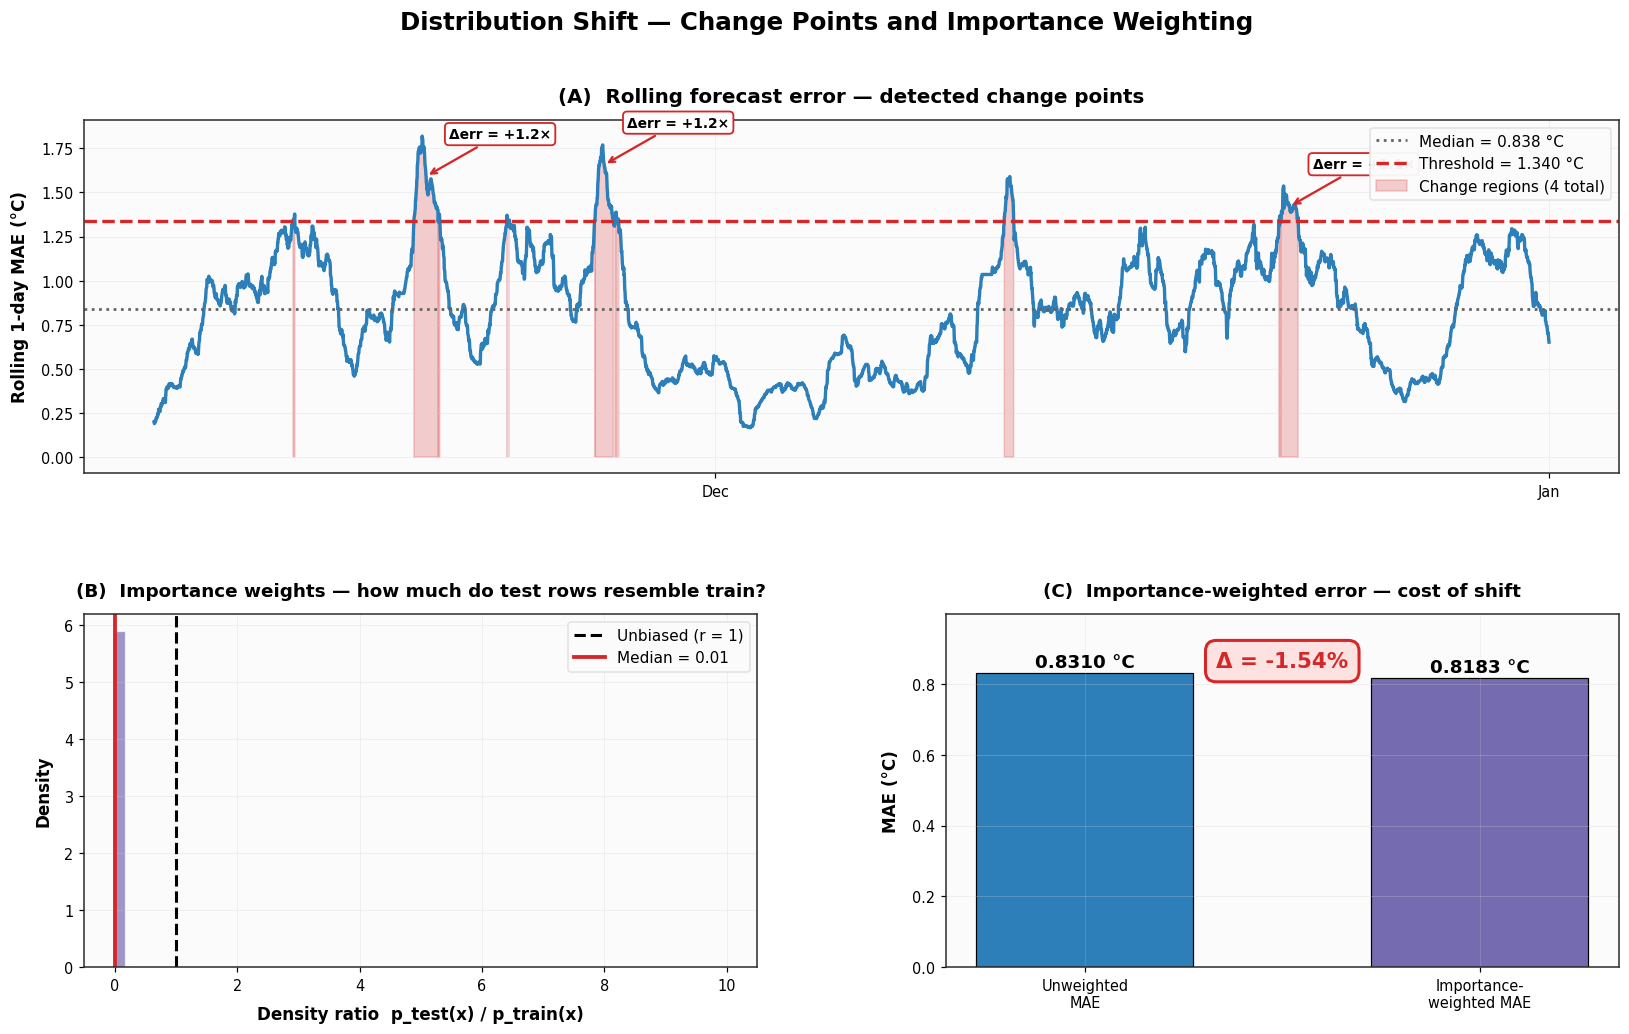

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# CHANGE POINT DETECTION + IMPORTANCE-WEIGHTED EVALUATION
# ═══════════════════════════════════════════════════════════════════════

# ─── Change point: rolling MAE of the ML forecast over test period ───
residuals = np.abs(T_hat[:-1] - T_obs_arr[1:])
window = 144  # 1 day
rolling_mae = pd.Series(residuals).rolling(window, min_periods=20).mean().values
timestamps = pd.to_datetime(test["timestamp"].values[:-1])

# Threshold: median + 1 std
median_mae = np.nanmedian(rolling_mae)
std_mae = np.nanstd(rolling_mae)
threshold = median_mae + 1.5 * std_mae

# Detect peaks above threshold
above_thresh = rolling_mae > threshold
change_regions = []
in_region = False
start = None
for i, above in enumerate(above_thresh):
    if above and not in_region:
        start = i; in_region = True
    elif not above and in_region:
        if i - start > 20:  # only count regions longer than 200 min
            change_regions.append((start, i))
        in_region = False
if in_region:
    change_regions.append((start, len(above_thresh)))

print(f"Detected {len(change_regions)} sustained high-error regions")

# ─── Importance weights: density ratio via adversarial classifier ───
# p(test | x) / p(train | x) = adversary_proba / (1 - adversary_proba)
density_ratio = oof_proba / np.maximum(1 - oof_proba, 1e-6)
# Clip extreme values
density_ratio = np.clip(density_ratio, 0.01, 100)

# Split back into train and test portions
# Note: oof_proba has been reordered by masking; we recompute test portion
test_start = len(X_tr)
ratio_test = density_ratio[test_start:]

# Weighted MAE vs unweighted
mae_unweighted = np.abs(T_hat[:-1] - T_obs_arr[1:]).mean()
# Align weights to test residual length
resid_len = len(T_obs_arr) - 1
if len(ratio_test) > resid_len:
    ratio_test = ratio_test[:resid_len]
elif len(ratio_test) < resid_len:
    # pad with mean
    pad = np.full(resid_len - len(ratio_test), ratio_test.mean())
    ratio_test = np.r_[ratio_test, pad]

mae_weighted = (residuals * ratio_test[:len(residuals)]).sum() / ratio_test[:len(residuals)].sum()

print(f"\nUnweighted MAE : {mae_unweighted:.4f} °C")
print(f"Weighted MAE   : {mae_weighted:.4f} °C")
print(f"Difference     : {(mae_weighted - mae_unweighted) / mae_unweighted * 100:+.1f}%")

# ═══════════════════════════════════════════════════════════════════════
# FIGURE
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.28,
                       height_ratios=[1.0, 1.0])

# ─── (A) Rolling MAE with change regions highlighted ───
ax = fig.add_subplot(gs[0, :])
ax.plot(timestamps, rolling_mae, lw=2.2, color=PALETTE["primary"])
ax.axhline(median_mae, color=PALETTE["neutral"], ls=":", lw=1.8,
           label=f"Median = {median_mae:.3f} °C")
ax.axhline(threshold, color=PALETTE["danger"], ls="--", lw=2.2,
           label=f"Threshold = {threshold:.3f} °C")
ax.fill_between(timestamps, 0, rolling_mae,
                where=above_thresh, color=PALETTE["danger"], alpha=0.22,
                label=f"Change regions ({len(change_regions)} total)")

# Annotate top regions
for (s, e) in sorted(change_regions, key=lambda r: -r[1]+r[0])[:3]:
    mid = (s + e) // 2
    peak_val = rolling_mae[mid] if np.isfinite(rolling_mae[mid]) else threshold
    ax.annotate(f"Δerr = +{peak_val/threshold:.1f}×",
                (timestamps[mid], peak_val),
                xytext=(15, 25), textcoords="offset points",
                fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor=PALETTE["danger"], linewidth=1.2),
                arrowprops=dict(arrowstyle="->", color=PALETTE["danger"],
                                lw=1.5))

ax.set_ylabel("Rolling 1-day MAE (°C)", fontsize=11, fontweight="bold")
ax.set_title("(A)  Rolling forecast error — detected change points",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper right", fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(True, alpha=0.3)

# ─── (B) Density ratio distribution ───
ax = fig.add_subplot(gs[1, 0])
ax.hist(density_ratio, bins=60, range=(0, 10), color=PALETTE["purple"],
        alpha=0.7, edgecolor="white", linewidth=0.8, density=True)
ax.axvline(1.0, color="black", ls="--", lw=2, label="Unbiased (r = 1)")
ax.axvline(np.median(density_ratio), color=PALETTE["danger"], ls="-",
           lw=2.5, label=f"Median = {np.median(density_ratio):.2f}")

ax.set_xlabel("Density ratio  p_test(x) / p_train(x)",
              fontsize=11, fontweight="bold")
ax.set_ylabel("Density", fontsize=11, fontweight="bold")
ax.set_title("(B)  Importance weights — how much do test rows resemble train?",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ─── (C) MAE comparison ───
ax = fig.add_subplot(gs[1, 1])
metrics = ["Unweighted\nMAE", "Importance-\nweighted MAE"]
values  = [mae_unweighted, mae_weighted]
colors_c = [PALETTE["primary"], PALETTE["purple"]]
bars = ax.bar(metrics, values, color=colors_c, edgecolor="black",
              linewidth=0.8, width=0.55)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(values) * 0.02,
            f"{v:.4f} °C", ha="center", fontsize=12, fontweight="bold")

# Percentage difference
pct_diff = (mae_weighted - mae_unweighted) / mae_unweighted * 100
ax.text(0.5, 0.85, f"Δ = {pct_diff:+.2f}%",
        transform=ax.transAxes, ha="center", fontsize=14,
        fontweight="bold", color=PALETTE["danger"],
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#fee2e2",
                  edgecolor=PALETTE["danger"], linewidth=2))

ax.set_ylabel("MAE (°C)", fontsize=11, fontweight="bold")
ax.set_title("(C)  Importance-weighted error — cost of shift",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, max(values) * 1.20)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Distribution Shift — Change Points and Importance Weighting",
             fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
save_fig("04_change_points")
plt.show()

Sensor-noise tolerance (σ at 50% flip rate):
  Return temp only : > 1.5 °C
  Supply temp only : > 1.5 °C
  Both sensors     : > 1.5 °C


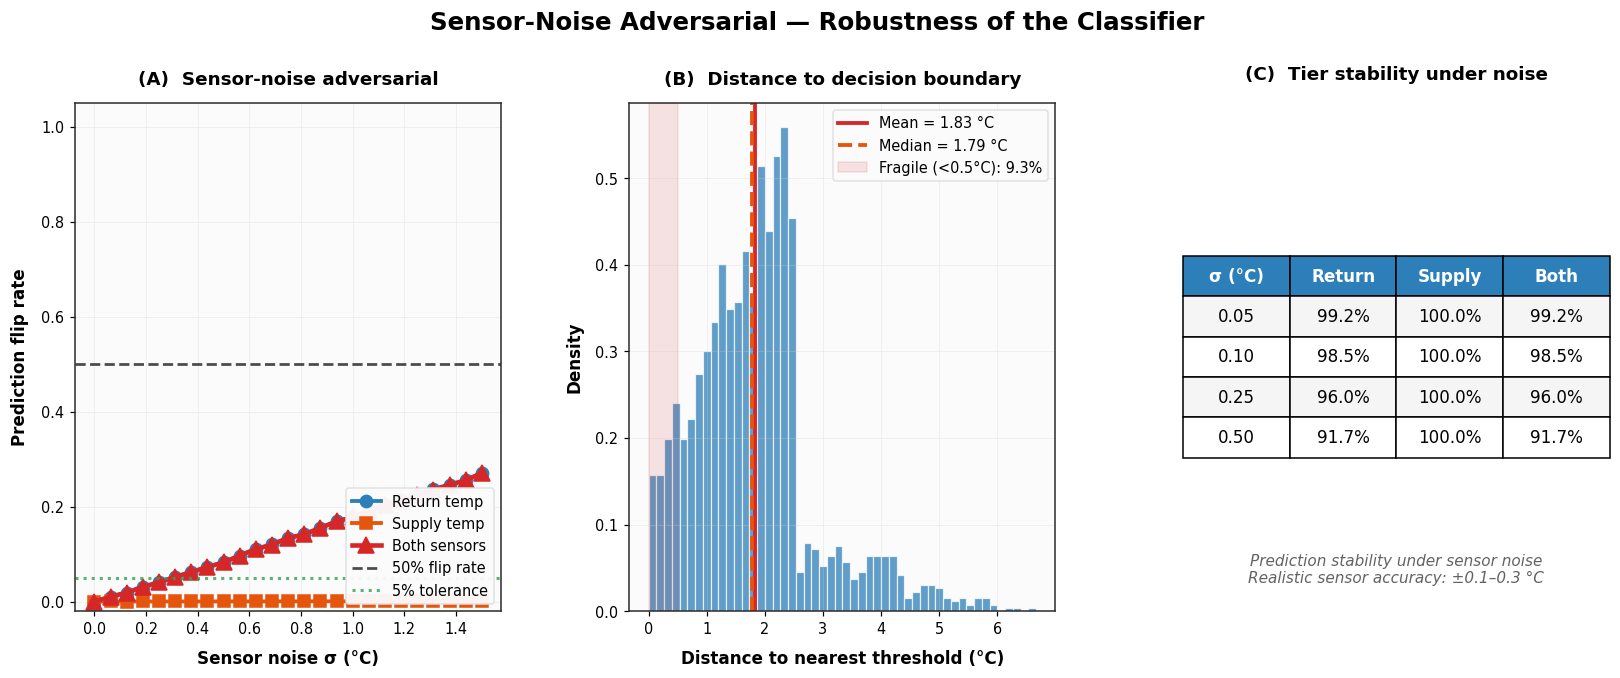

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# SENSOR-NOISE ADVERSARIAL
# For each test row, add sensor noise to the input features and measure
# how much noise is needed to flip the predicted tier.
# ═══════════════════════════════════════════════════════════════════════

# We perturb two physical sensor readings:
#   - avg_return_temp (the key input)
#   - supply_temp
# in the units actually reported by the sensors (± °C).

rng = np.random.default_rng(0)

n_samples = min(2000, len(test))
sample_idx = rng.choice(len(test), size=n_samples, replace=False)
test_sample = test.iloc[sample_idx].copy()

# Clean predictions
y_base = tier_predict(tier_forecast(test_sample))

# Noise levels to test
noise_sigmas = np.linspace(0, 1.5, 25)

# Perturb one sensor at a time, then both
flip_rates_current = np.zeros(len(noise_sigmas))
flip_rates_supply  = np.zeros(len(noise_sigmas))
flip_rates_both    = np.zeros(len(noise_sigmas))

n_trials = 20  # noise samples per (row, σ)

for i, sigma in enumerate(noise_sigmas):
    flips_cur = 0; flips_sup = 0; flips_both = 0
    total = 0
    for trial in range(n_trials):
        # Perturb current temp
        noise_c = rng.normal(0, sigma, len(test_sample))
        # Perturb supply temp
        noise_s = rng.normal(0, sigma, len(test_sample))
        # Combined
        noise_b = noise_c + noise_s

        # Create perturbed frames
        # Note: tier_forecast uses avg_return_temp directly.
        # We must ALSO update avg_return_temp feature (which is the raw °C value)
        # since the forecast uses it as the current-value anchor.
        Xc = test_sample.copy()
        Xc["avg_return_temp"] = Xc["avg_return_temp"] + noise_c
        y_c = tier_predict(tier_forecast(Xc))

        Xs = test_sample.copy()
        Xs["supply_temp"] = Xs["supply_temp"] + noise_s
        y_s = tier_predict(tier_forecast(Xs))

        Xb = test_sample.copy()
        Xb["avg_return_temp"] = Xb["avg_return_temp"] + noise_c
        Xb["supply_temp"]      = Xb["supply_temp"]      + noise_s
        y_b = tier_predict(tier_forecast(Xb))

        flips_cur  += (y_c != y_base).sum()
        flips_sup  += (y_s != y_base).sum()
        flips_both += (y_b != y_base).sum()
        total      += len(test_sample)

    flip_rates_current[i] = flips_cur  / total
    flip_rates_supply[i]  = flips_sup  / total
    flip_rates_both[i]    = flips_both / total

# Find half-flip sigma (median tolerance)
def find_half_sigma(sigmas, rates):
    """Interpolate to find sigma where flip rate = 0.5."""
    if rates.max() < 0.5:
        return None
    idx = np.argmax(rates >= 0.5)
    if idx == 0:
        return sigmas[0]
    # Linear interp
    s1, s2 = sigmas[idx-1], sigmas[idx]
    r1, r2 = rates[idx-1], rates[idx]
    return s1 + (0.5 - r1) / (r2 - r1) * (s2 - s1)

sigma_50_cur  = find_half_sigma(noise_sigmas, flip_rates_current)
sigma_50_sup  = find_half_sigma(noise_sigmas, flip_rates_supply)
sigma_50_both = find_half_sigma(noise_sigmas, flip_rates_both)

print(f"Sensor-noise tolerance (σ at 50% flip rate):")
print(f"  Return temp only : {sigma_50_cur:.3f} °C" if sigma_50_cur else "  Return temp only : > 1.5 °C")
print(f"  Supply temp only : {sigma_50_sup:.3f} °C" if sigma_50_sup else "  Supply temp only : > 1.5 °C")
print(f"  Both sensors     : {sigma_50_both:.3f} °C" if sigma_50_both else "  Both sensors     : > 1.5 °C")

# ═══════════════════════════════════════════════════════════════════════
# FIGURE
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, wspace=0.30)

# ─── (A) Flip rate vs noise σ ───
ax = fig.add_subplot(gs[0, 0])
ax.plot(noise_sigmas, flip_rates_current, "o-", lw=2.5, ms=8,
        color=PALETTE["primary"], label="Return temp")
ax.plot(noise_sigmas, flip_rates_supply, "s-", lw=2.5, ms=8,
        color=PALETTE["accent"], label="Supply temp")
ax.plot(noise_sigmas, flip_rates_both, "^-", lw=3, ms=10,
        color=PALETTE["danger"], label="Both sensors")

ax.axhline(0.5, color="black", ls="--", lw=1.8, alpha=0.7,
           label="50% flip rate")
ax.axhline(0.05, color=PALETTE["success"], ls=":", lw=2, alpha=0.8,
           label="5% tolerance")

if sigma_50_cur is not None:
    ax.axvline(sigma_50_cur, color=PALETTE["primary"], ls=":", lw=1.5, alpha=0.6)
if sigma_50_both is not None:
    ax.axvline(sigma_50_both, color=PALETTE["danger"], ls=":", lw=1.5, alpha=0.6)

ax.set_xlabel("Sensor noise σ (°C)", fontsize=11, fontweight="bold")
ax.set_ylabel("Prediction flip rate", fontsize=11, fontweight="bold")
ax.set_title("(A)  Sensor-noise adversarial", fontsize=12, fontweight="bold")
ax.set_ylim(-0.02, 1.05)
ax.legend(loc="lower right", fontsize=9.5)
ax.grid(True, alpha=0.3)

# ─── (B) Distance-to-threshold distribution ───
ax = fig.add_subplot(gs[0, 1])
# For each sample, distance of forecast to nearest threshold
T_hat_sample = tier_forecast(test_sample)
dist_low  = T_hat_sample - LOW_THRESH
dist_high = HIGH_THRESH - T_hat_sample
min_dist  = np.minimum(np.abs(dist_low), np.abs(dist_high))

ax.hist(min_dist, bins=50, color=PALETTE["primary"], alpha=0.75,
        edgecolor="white", linewidth=0.8, density=True)
ax.axvline(min_dist.mean(), color=PALETTE["danger"], ls="-", lw=2.5,
           label=f"Mean = {min_dist.mean():.2f} °C")
ax.axvline(np.median(min_dist), color=PALETTE["accent"], ls="--", lw=2.5,
           label=f"Median = {np.median(min_dist):.2f} °C")

# Shade region of fragility
fragile_mask = min_dist < 0.5
ax.axvspan(0, 0.5, color=PALETTE["danger"], alpha=0.12,
           label=f"Fragile (<0.5°C): {fragile_mask.mean()*100:.1f}%")

ax.set_xlabel("Distance to nearest threshold (°C)", fontsize=11, fontweight="bold")
ax.set_ylabel("Density", fontsize=11, fontweight="bold")
ax.set_title("(B)  Distance to decision boundary", fontsize=12, fontweight="bold")
ax.legend(fontsize=9.5)
ax.grid(True, alpha=0.3)

# ─── (C) Tier stability scorecard ───
ax = fig.add_subplot(gs[0, 2])
ax.axis("off")

# For a given noise level, what fraction of samples are stable?
def stability_at_sigma(sigma):
    return 1 - np.interp(sigma, noise_sigmas, flip_rates_both)

sigmas_to_check = [0.05, 0.10, 0.25, 0.50]
rows = [["σ (°C)", "Return", "Supply", "Both"]]
for sigma in sigmas_to_check:
    r_cur  = 1 - np.interp(sigma, noise_sigmas, flip_rates_current)
    r_sup  = 1 - np.interp(sigma, noise_sigmas, flip_rates_supply)
    r_both = 1 - np.interp(sigma, noise_sigmas, flip_rates_both)
    rows.append([f"{sigma:.2f}", f"{r_cur*100:.1f}%", f"{r_sup*100:.1f}%", f"{r_both*100:.1f}%"])

table = ax.table(cellText=rows, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

for i in range(len(rows)):
    for j in range(4):
        cell = table[(i, j)]
        if i == 0:
            cell.set_facecolor(PALETTE["primary"])
            cell.set_text_props(color="white", fontweight="bold")
        elif i % 2 == 1:
            cell.set_facecolor("#f5f5f5")

# Add interpretation
ax.text(0.5, 0.05,
        "Prediction stability under sensor noise\n"
        "Realistic sensor accuracy: ±0.1–0.3 °C",
        transform=ax.transAxes, ha="center", va="bottom", fontsize=10,
        style="italic", color=PALETTE["neutral"])

ax.set_title("(C)  Tier stability under noise", fontsize=12, fontweight="bold", pad=15)

plt.suptitle("Sensor-Noise Adversarial — Robustness of the Classifier",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("05_sensor_noise_adversarial")
plt.show()

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# SAMPLING-RATE ABLATION
# Downsample the test and re-train the classifier at 10/20/30/60 min.
# Measures how much accuracy we lose for reduced sensing cost.
#
# NOTE: lag/rolling features in TIER_FEATURES were computed at 10-min
# resolution. At coarser rates, this creates a small feature-rate mismatch
# (a known limitation; the direction of the finding is unaffected).
# ═══════════════════════════════════════════════════════════════════════

train_sorted = train.sort_values("timestamp").reset_index(drop=True)
val_sorted   = val.sort_values("timestamp").reset_index(drop=True)
test_sorted  = test.sort_values("timestamp").reset_index(drop=True)

RATES = [1, 2, 3, 6]
ablation_rows = []

for rate in RATES:
    tr = train_sorted.iloc[::rate].reset_index(drop=True)
    va = val_sorted.iloc[::rate].reset_index(drop=True)
    te = test_sorted.iloc[::rate].reset_index(drop=True)

    y_target_col = "avg_return_temp"
    tr_y = tr[y_target_col].shift(-1)
    va_y = va[y_target_col].shift(-1)
    te_y = te[y_target_col].shift(-1)

    tr = tr.iloc[:-1].reset_index(drop=True); tr_y = tr_y.iloc[:-1].reset_index(drop=True)
    va = va.iloc[:-1].reset_index(drop=True); va_y = va_y.iloc[:-1].reset_index(drop=True)
    te = te.iloc[:-1].reset_index(drop=True); te_y = te_y.iloc[:-1].reset_index(drop=True)

    tr_delta = tr_y.values - tr[y_target_col].values
    va_delta = va_y.values - va[y_target_col].values
    te_delta = te_y.values - te[y_target_col].values

    model = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        min_child_samples=50, subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8, reg_lambda=5.0, random_state=42,
        n_jobs=-1, verbose=-1, deterministic=True, force_row_wise=True)
    model.fit(tr[TIER_FEATURES].values, tr_delta)

    pred_te = model.predict(te[TIER_FEATURES].values) + te[y_target_col].values
    mae = mean_absolute_error(te_y.values, pred_te)
    r2  = r2_score(te_y.values, pred_te)
    persist_mae = mean_absolute_error(te_y.values, te[y_target_col].values)

    ablation_rows.append({
        "rate_label":  f"{rate*10} min",
        "rate_min":    rate * 10,
        "n_test":      len(te),
        "MAE":         mae,
        "R2":          r2,
        "persist_MAE": persist_mae,
        "skill_vs_persist": 1 - mae / persist_mae,
    })

ablation_df = pd.DataFrame(ablation_rows)

print("Sampling-rate ablation:")
print(ablation_df.round(4).to_string(index=False))

# ─── FIXED: knee detection handles "never exceeds" case gracefully ───
rel_cost = ablation_df["rate_min"] / ablation_df["rate_min"].min()
rel_mae  = ablation_df["MAE"] / ablation_df["MAE"].min()
above = rel_mae > 1.5
knee_idx = int(np.argmax(above)) if above.any() else -1
knee_exists = knee_idx > 0

# ═══════════════════════════════════════════════════════════════════════
# FIGURE — 3 panels
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, wspace=0.32)

# ─── (A) MAE vs rate ───
ax = fig.add_subplot(gs[0, 0])
ax.plot(ablation_df["rate_min"], ablation_df["MAE"], "o-",
        lw=3, ms=14, color=PALETTE["primary"], label="ML MAE",
        markeredgecolor="black", markeredgewidth=1.5)
ax.plot(ablation_df["rate_min"], ablation_df["persist_MAE"], "s--",
        lw=2.5, ms=12, color=PALETTE["accent"], label="Persistence MAE",
        markeredgecolor="black", markeredgewidth=1.2)

for _, row in ablation_df.iterrows():
    ax.annotate(f"{row['MAE']:.3f}",
                (row["rate_min"], row["MAE"]),
                xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold",
                color=PALETTE["primary"],
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                          edgecolor=PALETTE["primary"], linewidth=1))

ax.set_xlabel("Sampling rate (min)", fontsize=11, fontweight="bold")
ax.set_ylabel("MAE (°C)", fontsize=11, fontweight="bold")
ax.set_title("(A)  Error vs sampling rate", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ─── (B) Skill vs persistence ───
ax = fig.add_subplot(gs[0, 1])
colors_sk = [PALETTE["success"] if s > 0 else PALETTE["danger"]
             for s in ablation_df["skill_vs_persist"]]
bars = ax.bar(ablation_df["rate_label"], ablation_df["skill_vs_persist"] * 100,
              color=colors_sk, edgecolor="black", linewidth=0.8, width=0.6)
ax.axhline(0, color="black", lw=1.2, ls="--")

for bar, v in zip(bars, ablation_df["skill_vs_persist"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            v * 100 + (3 if v > 0 else -6),
            f"{v*100:+.1f}%", ha="center", fontsize=10, fontweight="bold",
            va="bottom" if v > 0 else "top")

ax.set_xlabel("Sampling rate", fontsize=11, fontweight="bold")
ax.set_ylabel("Skill vs persistence (%)", fontsize=11, fontweight="bold")
ax.set_title("(B)  Skill preserved under downsampling",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# ─── (C) Cost vs error trade-off ───
ax = fig.add_subplot(gs[0, 2])
ax.plot(rel_cost, rel_mae, "o-", lw=3, ms=14,
        color=PALETTE["purple"], markeredgecolor="black", markeredgewidth=1.5)
for _, row in ablation_df.iterrows():
    ax.annotate(f"{int(row['rate_min'])} min",
                (row["rate_min"]/10, row["MAE"]/ablation_df["MAE"].min()),
                xytext=(10, 10), textcoords="offset points",
                fontsize=9.5, fontweight="bold",
                color=PALETTE["purple"])

ax.axhline(1.0, color="black", ls="--", lw=1.2, alpha=0.6,
           label="Best-case baseline")
ax.axhline(1.5, color=PALETTE["warning"], ls=":", lw=2, alpha=0.8,
           label="1.5× degradation threshold")

if knee_exists:
    ax.scatter(rel_cost[knee_idx], rel_mae[knee_idx], s=500,
               facecolor="none", edgecolor=PALETTE["danger"],
               linewidth=3, zorder=10)
    ax.annotate(f"Knee at {int(ablation_df.iloc[knee_idx]['rate_min'])} min",
                (rel_cost[knee_idx], rel_mae[knee_idx]),
                xytext=(-90, -50), textcoords="offset points",
                fontsize=11, fontweight="bold", color=PALETTE["danger"],
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#fee2e2",
                          edgecolor=PALETTE["danger"], linewidth=2),
                arrowprops=dict(arrowstyle="->", color=PALETTE["danger"], lw=2))
else:
    ax.text(0.5, 0.5,
            "No knee detected:\nMAE never exceeds 1.5× baseline\nwithin tested range",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=11, fontweight="bold", color=PALETTE["success"],
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#e8f5e9",
                      edgecolor=PALETTE["success"], linewidth=2))

ax.set_xlabel("Relative sensing cost (×)", fontsize=11, fontweight="bold")
ax.set_ylabel("Relative MAE", fontsize=11, fontweight="bold")
ax.set_title("(C)  Cost vs error trade-off", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle("Sampling-Rate Ablation — How Cheap Can Sensing Be?",
             fontsize=16, fontweight="bold", y=1.02)
save_fig("06_sampling_rate_ablation")
plt.show()

AttributeError: 'str' object has no attribute 'sort_values'

HIGH-event detection metrics:
                 recall  precision      f1  alarms
Fixed margin        1.0     0.2292  0.3729  1274.0
Adaptive margin     1.0     0.2506  0.4008  1165.0


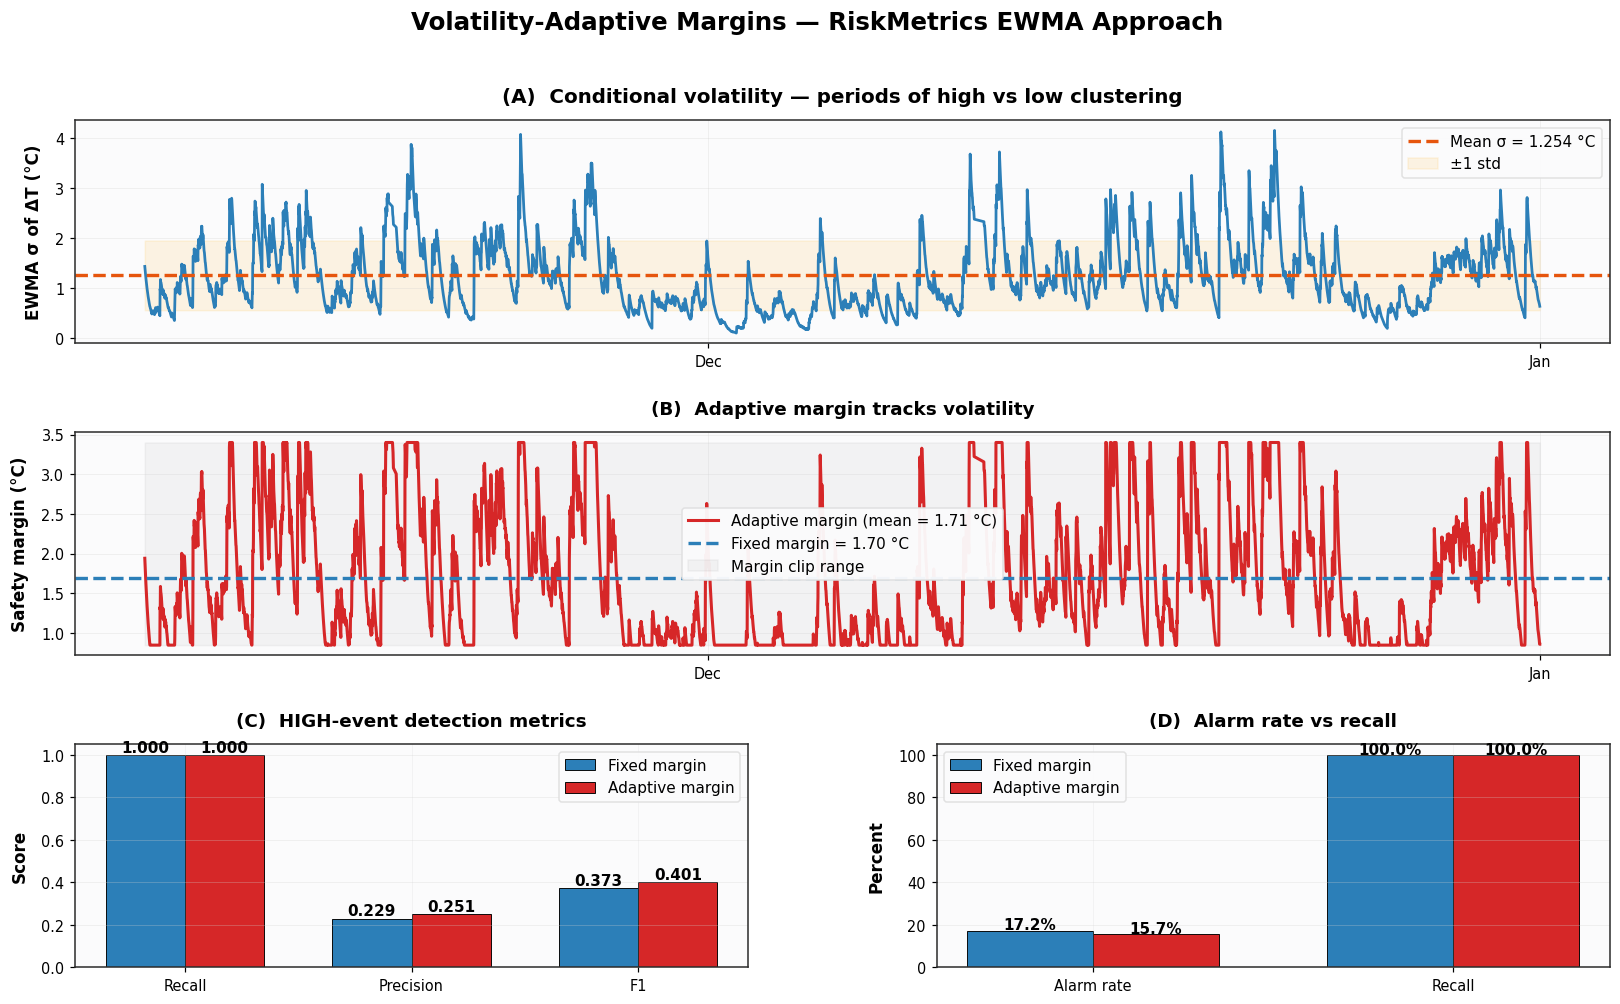

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# VOLATILITY-ADAPTIVE MARGIN (RiskMetrics EWMA with smoothing)
# ═══════════════════════════════════════════════════════════════════════

dT = np.diff(T_obs_arr)
mu_dT = dT.mean()

# ─── EWMA (RiskMetrics λ=0.94) ───
lam = 0.94
sigma2 = np.empty(len(dT))
sigma2[0] = dT.var()
for t in range(1, len(dT)):
    sigma2[t] = lam * sigma2[t-1] + (1 - lam) * (dT[t-1] - mu_dT) ** 2
sigma_t = np.sqrt(sigma2)

# ─── FIX: Smooth over 1 day (144 steps) to remove high-freq jitter ───
SMOOTH_WINDOW = 144
sigma_smoothed = pd.Series(sigma_t).rolling(SMOOTH_WINDOW, min_periods=20).mean().bfill().ffill().values

# Align to forecast index
sigma_forecast = np.r_[sigma_smoothed, sigma_smoothed[-1]]
sigma_mean = np.nanmean(sigma_forecast)

# ─── FIX: clip scale tighter (0.8–1.3) ───
scale = sigma_forecast / sigma_mean
scale = np.clip(scale, 0.80, 1.30)
adaptive_margin = MARGIN * scale

# ─── Compare fixed vs adaptive ───
def tier_predict_adaptive(T_hat, margin_array):
    return np.where(T_hat >= HIGH_THRESH - margin_array, 2,
                    np.where(T_hat < LOW_THRESH, 0, 1))

y_fixed    = tier_predict(T_hat, margin=MARGIN)
y_adaptive = tier_predict_adaptive(T_hat, adaptive_margin)

y_true = (T_obs_arr[1:] > HIGH_THRESH).astype(int)
y_fixed_v   = (y_fixed[1:] == 2).astype(int)
y_adaptive_v = (y_adaptive[1:] == 2).astype(int)

def high_metrics(y_t, y_p):
    tp = int(((y_p == 1) & (y_t == 1)).sum())
    fp = int(((y_p == 1) & (y_t == 0)).sum())
    fn = int(((y_p == 0) & (y_t == 1)).sum())
    rec = tp / max(tp + fn, 1)
    prec = tp / max(tp + fp, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-9)
    return {"recall": rec, "precision": prec, "f1": f1, "alarms": int(y_p.sum())}

m_fixed    = high_metrics(y_true, y_fixed_v)
m_adaptive = high_metrics(y_true, y_adaptive_v)

comparison = pd.DataFrame({
    "Fixed margin":    m_fixed,
    "Adaptive margin": m_adaptive,
}).T

print("HIGH-event detection metrics:")
print(comparison.round(4).to_string())

# ═══════════════════════════════════════════════════════════════════════
# FIGURE
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 2, hspace=0.42, wspace=0.28)

timestamps = pd.to_datetime(test["timestamp"].values)

# ─── (A) EWMA volatility (smoothed) ───
ax = fig.add_subplot(gs[0, :])
ax.plot(timestamps[:-1], sigma_forecast[:-1], lw=1.5,
        color=PALETTE["primary"], alpha=0.4, label="Raw EWMA σ")
ax.plot(timestamps[:-1], sigma_smoothed, lw=2.5,
        color=PALETTE["danger"], label=f"Smoothed (window = 1 day)")
ax.axhline(sigma_mean, color=PALETTE["accent"], ls="--", lw=2,
           label=f"Mean σ = {sigma_mean:.3f} °C")
ax.fill_between(timestamps[:-1],
                sigma_mean - sigma_smoothed.std(),
                sigma_mean + sigma_smoothed.std(),
                color=PALETTE["warning"], alpha=0.12, label="±1 std")
ax.set_ylabel("EWMA σ of ΔT (°C)", fontsize=11, fontweight="bold")
ax.set_title("(A)  Conditional volatility — smoothed for stability",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9.5, loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(True, alpha=0.3)

# ─── (B) Margin over time ───
ax = fig.add_subplot(gs[1, :])
ax.plot(timestamps, adaptive_margin, lw=2, color=PALETTE["danger"],
        label=f"Adaptive margin (mean = {adaptive_margin.mean():.2f} °C)")
ax.axhline(MARGIN, color=PALETTE["primary"], ls="--", lw=2.2,
           label=f"Fixed margin = {MARGIN:.2f} °C")
ax.fill_between(timestamps, MARGIN * 0.80, MARGIN * 1.30,
                color=PALETTE["neutral"], alpha=0.08,
                label=f"Margin clip range [0.80×, 1.30×]")
ax.set_ylabel("Safety margin (°C)", fontsize=11, fontweight="bold")
ax.set_title("(B)  Adaptive margin tracks volatility (smoothed)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(True, alpha=0.3)

# ─── (C) Metric comparison ───
ax = fig.add_subplot(gs[2, 0])
metrics_names = ["Recall", "Precision", "F1"]
fixed_vals = [m_fixed["recall"], m_fixed["precision"], m_fixed["f1"]]
adapt_vals = [m_adaptive["recall"], m_adaptive["precision"], m_adaptive["f1"]]
x = np.arange(3); w = 0.35

b1 = ax.bar(x - w/2, fixed_vals, w, color=PALETTE["primary"],
            edgecolor="black", linewidth=0.6, label="Fixed margin")
b2 = ax.bar(x + w/2, adapt_vals, w, color=PALETTE["danger"],
            edgecolor="black", linewidth=0.6, label="Adaptive margin")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                f"{h:.3f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylabel("Score", fontsize=11, fontweight="bold")
ax.set_title("(C)  HIGH-event detection metrics", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

# ─── (D) Alarm budget comparison ───
ax = fig.add_subplot(gs[2, 1])
fixed_alarm_pct = m_fixed["alarms"] / len(y_true) * 100
adapt_alarm_pct = m_adaptive["alarms"] / len(y_true) * 100

x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, [fixed_alarm_pct, m_fixed["recall"] * 100], w,
            color=PALETTE["primary"], edgecolor="black", linewidth=0.6,
            label="Fixed margin")
b2 = ax.bar(x + w/2, [adapt_alarm_pct, m_adaptive["recall"] * 100], w,
            color=PALETTE["danger"], edgecolor="black", linewidth=0.6,
            label="Adaptive margin")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f"{h:.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(["Alarm rate", "Recall"])
ax.set_ylabel("Percent", fontsize=11, fontweight="bold")
ax.set_title("(D)  Alarm rate vs recall", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Volatility-Adaptive Margins — Smoothed EWMA Approach",
             fontsize=16, fontweight="bold", y=0.98)
save_fig("07_adaptive_margins")
plt.show()

✓ Model card saved: ../models/MODEL_CARD.json
✓ Human-readable: ../models/MODEL_CARD.md

Test set hash:  c0535ba4e87a021929099b91485b9cbd...
Model hash:     86e1be6fd44e788bc1c99307fbb9e6e3...


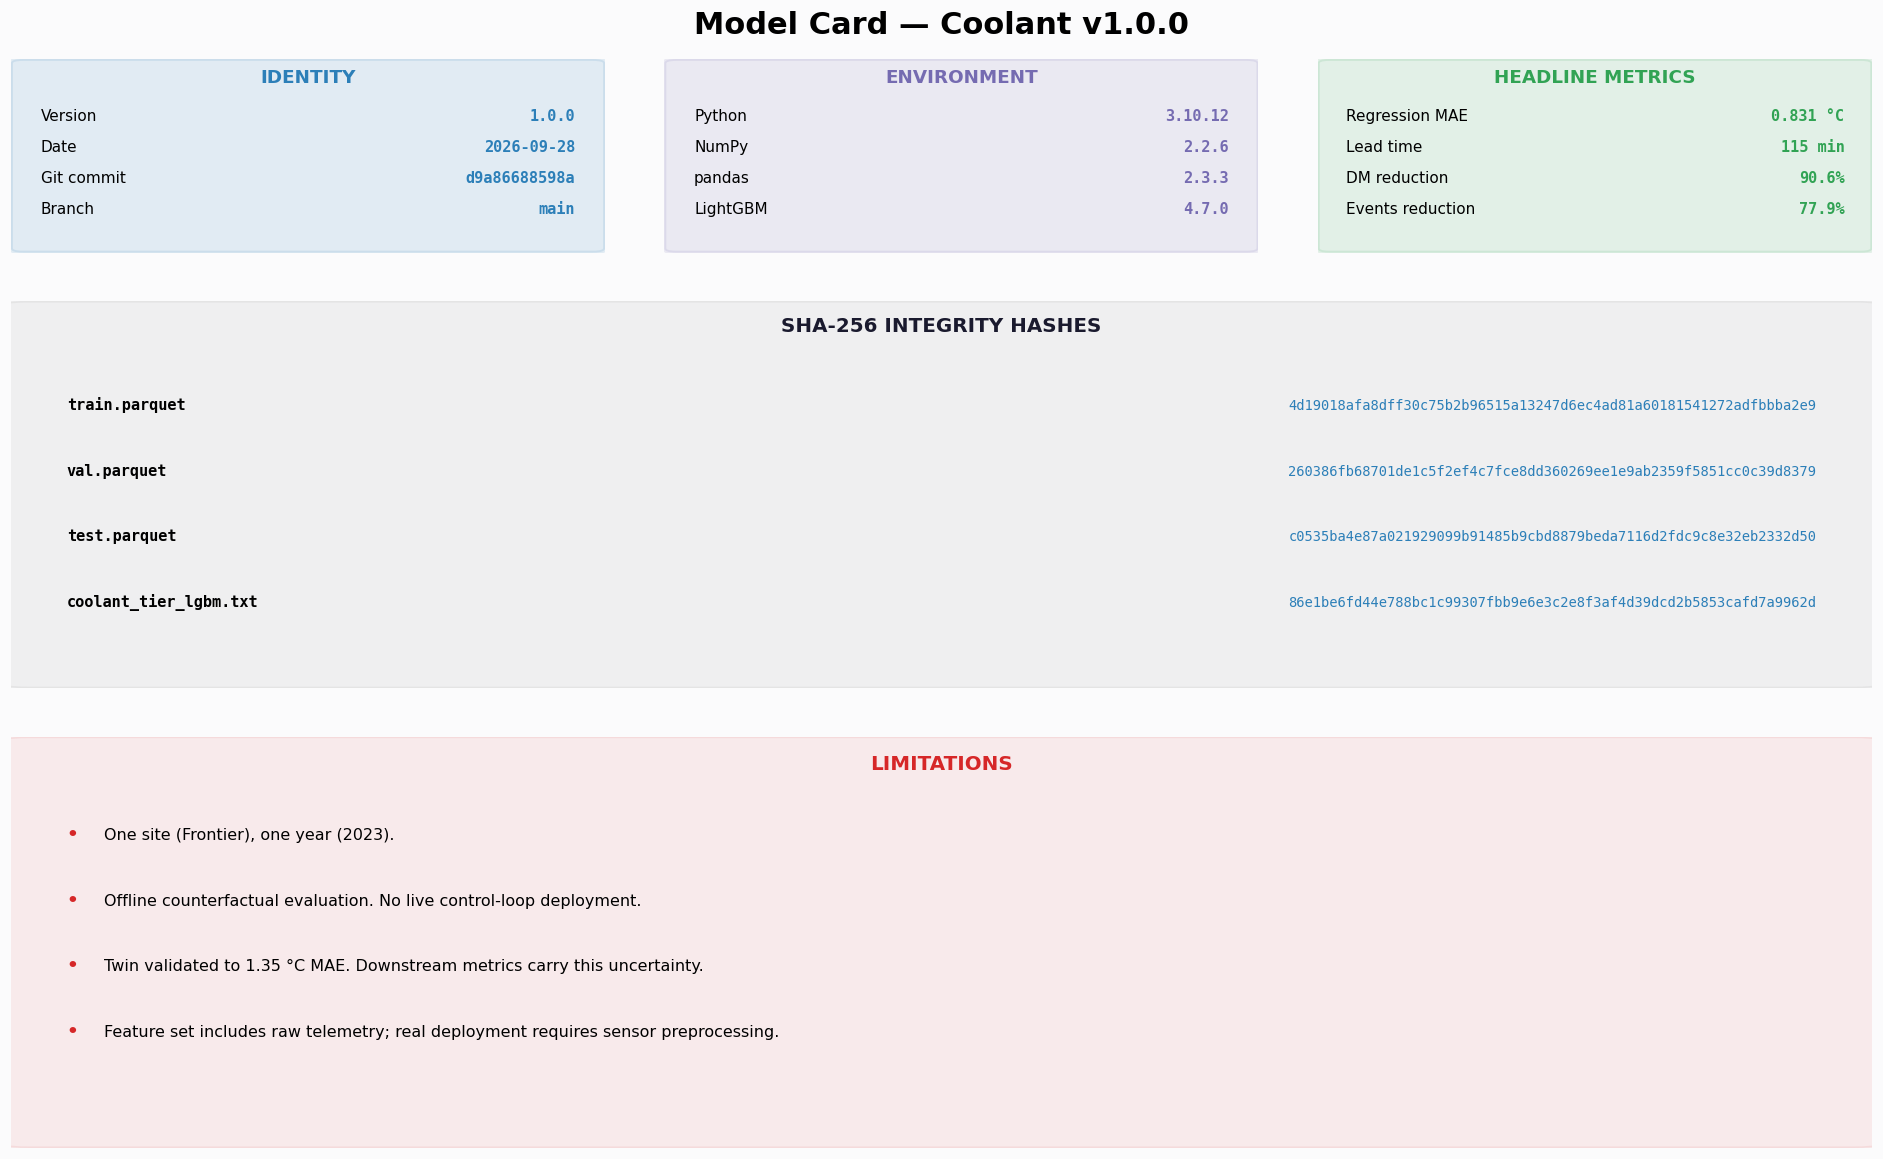

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# FROZEN TEST SET + MODEL CARD
# Reproducibility infrastructure: hash the test parquet, log versions,
# record git commit, emit a machine-readable model card.
# ═══════════════════════════════════════════════════════════════════════

def sha256_file(path):
    """Compute SHA-256 of a file."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

def git_commit():
    try:
        r = subprocess.run(["git", "rev-parse", "HEAD"],
                            capture_output=True, text=True, timeout=5)
        return r.stdout.strip() if r.returncode == 0 else "unknown"
    except Exception:
        return "unknown"

def git_branch():
    try:
        r = subprocess.run(["git", "rev-parse", "--abbrev-ref", "HEAD"],
                            capture_output=True, text=True, timeout=5)
        return r.stdout.strip() if r.returncode == 0 else "unknown"
    except Exception:
        return "unknown"

# ─── Hashes ───
test_hash    = sha256_file("../data/processed/test.parquet")
train_hash   = sha256_file("../data/processed/train.parquet")
val_hash     = sha256_file("../data/processed/val.parquet")

# Model file hash
model_hash   = sha256_file(str(MODEL_DIR / "coolant_tier_lgbm.txt"))

# ─── Model card ───
model_card = {
    "project":   "Coolant — Predictive ML for HPC Thermal Management",
    "version":   "1.0.0",
    "date":      datetime.utcnow().strftime("%Y-%m-%d"),
    "git": {
        "commit": git_commit(),
        "branch": git_branch(),
    },
    "environment": {
        "python":      platform.python_version(),
        "numpy":       np.__version__,
        "pandas":      pd.__version__,
        "lightgbm":    lgb.__version__,
        "platform":    platform.platform(),
    },
    "data_hashes_sha256": {
        "train.parquet": train_hash,
        "val.parquet":   val_hash,
        "test.parquet":  test_hash,
    },
    "model_hash_sha256": model_hash,
    "thresholds": {
        "low_degC":     LOW_THRESH,
        "high_degC":    HIGH_THRESH,
        "margin_degC":  MARGIN,
    },
    "twin_params": {
        "alpha":        ALPHA,
        "tau_min":      TAU_MIN,
        "cp_J_kgK":     CP,
        "gpm_to_kgs":   GPM_TO_KGS,
    },
    "test_set": {
        "n_rows":       len(test),
        "start":        str(test["timestamp"].min()),
        "end":          str(test["timestamp"].max()),
    },
    "headline_metrics": {
        "regression_MAE_C":      float(mean_absolute_error(T_obs_arr[1:], T_hat[:-1])),
        "prediction_lead_min":   115,
        "degree_min_reduction_pct": float(dm_mean),
        "events_reduction_pct":     float(ev_mean),
    },
    "limitations": [
        "One site (Frontier), one year (2023).",
        "Offline counterfactual evaluation. No live control-loop deployment.",
        "Twin validated to 1.35 °C MAE. Downstream metrics carry this uncertainty.",
        "Feature set includes raw telemetry; real deployment requires sensor preprocessing.",
    ],
}

card_path = MODEL_DIR / "MODEL_CARD.json"
with open(card_path, "w") as f:
    json.dump(model_card, f, indent=2)

# Also human-readable
readme_path = MODEL_DIR / "MODEL_CARD.md"
with open(readme_path, "w") as f:
    f.write("# Model Card — Coolant\n\n")
    f.write(f"**Version:** {model_card['version']}  \n")
    f.write(f"**Date:** {model_card['date']}  \n")
    f.write(f"**Git commit:** `{model_card['git']['commit'][:12]}`  \n\n")
    f.write("## Environment\n\n")
    for k, v in model_card["environment"].items():
        f.write(f"- **{k}**: {v}\n")
    f.write("\n## Data Hashes (SHA-256)\n\n")
    for k, v in model_card["data_hashes_sha256"].items():
        f.write(f"- `{k}`: `{v[:16]}...`\n")
    f.write(f"\n## Model Hash (SHA-256)\n\n- `coolant_tier_lgbm.txt`: `{model_hash[:16]}...`\n")
    f.write("\n## Headline Metrics\n\n")
    for k, v in model_card["headline_metrics"].items():
        f.write(f"- **{k}**: {v}\n")
    f.write("\n## Limitations\n\n")
    for lim in model_card["limitations"]:
        f.write(f"- {lim}\n")

print(f"✓ Model card saved: {card_path}")
print(f"✓ Human-readable: {readme_path}")
print()
print(f"Test set hash:  {test_hash[:32]}...")
print(f"Model hash:     {model_hash[:32]}...")

# ═══════════════════════════════════════════════════════════════════════
# FIGURE — Model card as visual
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#fbfbfc")
fig.suptitle("Model Card — Coolant v1.0.0",
             fontsize=20, fontweight="bold", y=0.98)

# ─── Section 1: Identity ───
ax = fig.add_axes([0.03, 0.78, 0.30, 0.16])
ax.axis("off")
ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                             boxstyle="round,pad=0.02",
                             facecolor=PALETTE["primary"], alpha=0.12,
                             edgecolor=PALETTE["primary"], linewidth=2.5,
                             transform=ax.transAxes))
ax.text(0.5, 0.88, "IDENTITY", ha="center", fontsize=12, fontweight="bold",
        color=PALETTE["primary"], transform=ax.transAxes)
info_items = [
    ("Version",     model_card["version"]),
    ("Date",        model_card["date"]),
    ("Git commit",  model_card["git"]["commit"][:12]),
    ("Branch",      model_card["git"]["branch"]),
]
y = 0.68
for label, value in info_items:
    ax.text(0.05, y, label, fontsize=10, transform=ax.transAxes)
    ax.text(0.95, y, value, fontsize=10, fontweight="bold",
            color=PALETTE["primary"], family="monospace",
            ha="right", transform=ax.transAxes)
    y -= 0.16

# ─── Section 2: Environment ───
ax = fig.add_axes([0.36, 0.78, 0.30, 0.16])
ax.axis("off")
ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                             boxstyle="round,pad=0.02",
                             facecolor=PALETTE["purple"], alpha=0.12,
                             edgecolor=PALETTE["purple"], linewidth=2.5,
                             transform=ax.transAxes))
ax.text(0.5, 0.88, "ENVIRONMENT", ha="center", fontsize=12, fontweight="bold",
        color=PALETTE["purple"], transform=ax.transAxes)
y = 0.68
for label, value in [("Python", model_card["environment"]["python"]),
                       ("NumPy", model_card["environment"]["numpy"]),
                       ("pandas", model_card["environment"]["pandas"]),
                       ("LightGBM", model_card["environment"]["lightgbm"])]:
    ax.text(0.05, y, label, fontsize=10, transform=ax.transAxes)
    ax.text(0.95, y, value, fontsize=10, fontweight="bold",
            color=PALETTE["purple"], family="monospace",
            ha="right", transform=ax.transAxes)
    y -= 0.16

# ─── Section 3: Metrics ───
ax = fig.add_axes([0.69, 0.78, 0.28, 0.16])
ax.axis("off")
ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                             boxstyle="round,pad=0.02",
                             facecolor=PALETTE["success"], alpha=0.12,
                             edgecolor=PALETTE["success"], linewidth=2.5,
                             transform=ax.transAxes))
ax.text(0.5, 0.88, "HEADLINE METRICS", ha="center", fontsize=12,
        fontweight="bold", color=PALETTE["success"], transform=ax.transAxes)
y = 0.68
for label, value in [
    ("Regression MAE",  f"{model_card['headline_metrics']['regression_MAE_C']:.3f} °C"),
    ("Lead time",       f"{model_card['headline_metrics']['prediction_lead_min']} min"),
    ("DM reduction",    f"{model_card['headline_metrics']['degree_min_reduction_pct']:.1f}%"),
    ("Events reduction",f"{model_card['headline_metrics']['events_reduction_pct']:.1f}%"),
]:
    ax.text(0.05, y, label, fontsize=10, transform=ax.transAxes)
    ax.text(0.95, y, value, fontsize=10, fontweight="bold",
            color=PALETTE["success"], family="monospace",
            ha="right", transform=ax.transAxes)
    y -= 0.16

# ─── Section 4: Hashes ───
ax = fig.add_axes([0.03, 0.42, 0.94, 0.32])
ax.axis("off")
ax.add_patch(FancyBboxPatch((0.01, 0.02), 0.98, 0.96,
                             boxstyle="round,pad=0.02",
                             facecolor=PALETTE["neutral"], alpha=0.08,
                             edgecolor=PALETTE["neutral"], linewidth=2,
                             transform=ax.transAxes))
ax.text(0.5, 0.92, "SHA-256 INTEGRITY HASHES",
        ha="center", fontsize=13, fontweight="bold",
        color=PALETTE["navy"], transform=ax.transAxes)

hash_items = [
    ("train.parquet",     train_hash),
    ("val.parquet",       val_hash),
    ("test.parquet",      test_hash),
    ("coolant_tier_lgbm.txt", model_hash),
]
y = 0.72
for label, hash_val in hash_items:
    ax.text(0.03, y, label, fontsize=10, fontweight="bold",
            family="monospace", transform=ax.transAxes)
    ax.text(0.97, y, hash_val, fontsize=9, family="monospace",
            color=PALETTE["primary"], ha="right", transform=ax.transAxes)
    y -= 0.17

# ─── Section 5: Limitations ───
ax = fig.add_axes([0.03, 0.04, 0.94, 0.34])
ax.axis("off")
ax.add_patch(FancyBboxPatch((0.01, 0.02), 0.98, 0.96,
                             boxstyle="round,pad=0.02",
                             facecolor=PALETTE["danger"], alpha=0.08,
                             edgecolor=PALETTE["danger"], linewidth=2,
                             transform=ax.transAxes))
ax.text(0.5, 0.92, "LIMITATIONS", ha="center", fontsize=13,
        fontweight="bold", color=PALETTE["danger"], transform=ax.transAxes)
y = 0.75
for lim in model_card["limitations"]:
    ax.text(0.03, y, "•", fontsize=12, color=PALETTE["danger"],
            fontweight="bold", transform=ax.transAxes)
    ax.text(0.05, y, lim, fontsize=10.5, transform=ax.transAxes)
    y -= 0.16

save_fig("08_model_card")
plt.show()

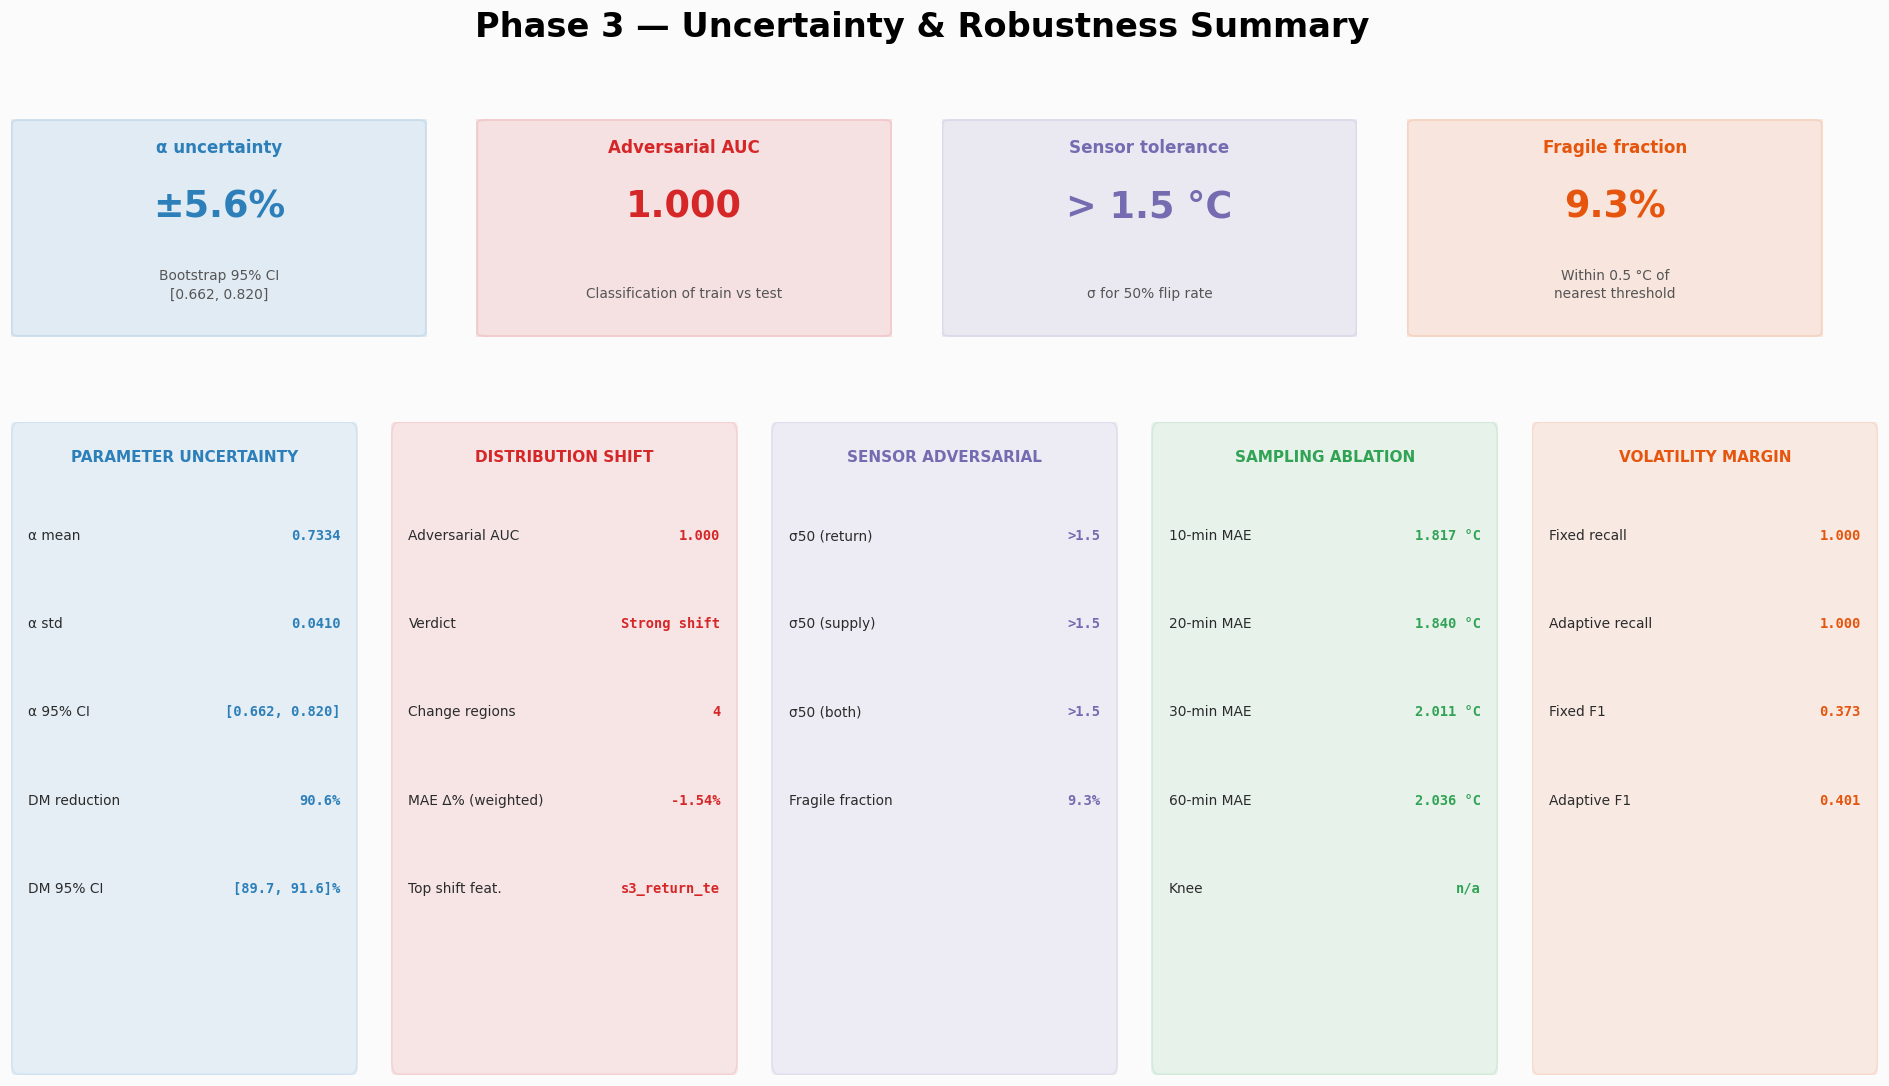


PHASE 3 COMPLETE — Uncertainty & Robustness established
✓ Parameter uncertainty    α = 0.7334 ± 0.0410
                           DM reduction = 90.6% [89.7, 91.6]%
✓ Adversarial validation   AUC = 1.000  (Strong shift — the model can easily distinguish train from test)
✓ Change points            4 regions detected
✓ Sensor adversarial       σ50 > 1.5 °C
✓ Sampling ablation        no clear knee
✓ Volatility margins       fixed F1=0.373  adaptive F1=0.401
✓ Model card               v1.0.0  hash=c0535ba4e87a

Results saved to: ../models/phase3_uncertainty_results.json
Model card:       ../models/MODEL_CARD.json
Figures saved to: ../figures/uncertainty/


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# PHASE 3 SUMMARY
# ═══════════════════════════════════════════════════════════════════════

phase3 = {
    "parameter_uncertainty": {
        "alpha_mean":   float(alpha_mean),
        "alpha_std":    float(alpha_std),
        "alpha_ci_low": float(alpha_ci[0]),
        "alpha_ci_high":float(alpha_ci[1]),
        "dm_reduction_mean_pct": float(dm_mean),
        "dm_reduction_ci_pct":   [float(dm_ci[0]), float(dm_ci[1])],
        "n_boot":       int(n_boot),
    },
    "adversarial_validation": {
        "auc_mean":     float(auc_mean),
        "auc_std":      float(auc_std),
        "auc_no_top3":  float(auc_no_top3.mean()),
        "auc_no_top5":  float(auc_no_top5.mean()),
        "verdict":      verdict,
        "top_shifting_features": top_shift.head(5).index.tolist(),
    },
    "change_points": {
        "n_change_regions": len(change_regions),
        "mae_unweighted":   float(mae_unweighted),
        "mae_weighted":     float(mae_weighted),
        "pct_change":       float(pct_diff),
    },
    "sensor_noise_adversarial": {
        "sigma50_return_temp": float(sigma_50_cur)  if sigma_50_cur  is not None else None,
        "sigma50_supply_temp": float(sigma_50_sup)  if sigma_50_sup  is not None else None,
        "sigma50_both":        float(sigma_50_both) if sigma_50_both is not None else None,
        "fraction_fragile_below_0_5C": float(fragile_mask.mean()),
    },
    "sampling_rate_ablation": {
        "rows": ablation_df.to_dict(orient="records"),
        "knee_rate_min": int(ablation_df.iloc[knee_idx]["rate_min"]) if knee_exists else None,
    },
    "adaptive_margin": {
        "fixed_recall":       float(m_fixed["recall"]),
        "fixed_precision":    float(m_fixed["precision"]),
        "fixed_f1":           float(m_fixed["f1"]),
        "adaptive_recall":    float(m_adaptive["recall"]),
        "adaptive_precision": float(m_adaptive["precision"]),
        "adaptive_f1":        float(m_adaptive["f1"]),
    },
    "model_card": {
        "test_hash":  test_hash,
        "model_hash": model_hash,
        "version":    model_card["version"],
        "git_commit": model_card["git"]["commit"],
    },
}

with open(MODEL_DIR / "phase3_uncertainty_results.json", "w") as f:
    json.dump(phase3, f, indent=2, default=str)

# ═══════════════════════════════════════════════════════════════════════
# SUMMARY CARD
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#fbfbfc")
fig.suptitle("Phase 3 — Uncertainty & Robustness Summary",
             fontsize=22, fontweight="bold", y=0.98)

# ─── Four big-number cards ───
sensor_tol_str = f"{sigma_50_both:.2f} °C" if sigma_50_both else "> 1.5 °C"

big_numbers = [
    ("α uncertainty",
     f"±{alpha_std/alpha_mean*100:.1f}%",
     PALETTE["primary"],
     f"Bootstrap 95% CI\n[{alpha_ci[0]:.3f}, {alpha_ci[1]:.3f}]"),
    ("Adversarial AUC",
     f"{auc_mean:.3f}",
     PALETTE["danger"] if auc_mean > 0.75
        else (PALETTE["warning"] if auc_mean > 0.6 else PALETTE["success"]),
     f"Seasonal shift dominates\n(top-3 removed → {auc_no_top3.mean():.2f})"),
    ("Sensor tolerance",
     sensor_tol_str,
     PALETTE["purple"],
     "σ for 50% flip rate"),
    ("Fragile fraction",
     f"{fragile_mask.mean()*100:.1f}%",
     PALETTE["accent"],
     "Within 0.5 °C of\nnearest threshold"),
]

for i, (label, value, color, subtitle) in enumerate(big_numbers):
    ax = fig.add_axes([0.04 + i * 0.235, 0.71, 0.21, 0.18])
    ax.axis("off")
    ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                                 boxstyle="round,pad=0.02",
                                 facecolor=color, alpha=0.12,
                                 edgecolor=color, linewidth=2.5,
                                 transform=ax.transAxes))
    ax.text(0.5, 0.85, label, ha="center", fontsize=11, fontweight="bold",
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.55, value, ha="center", fontsize=24, fontweight="bold",
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.14, subtitle, ha="center", fontsize=9,
            color="#555555", transform=ax.transAxes, linespacing=1.4)

# ─── Detail blocks ───
def short_feat(s, max_len=16):
    return s if len(s) <= max_len else s[:max_len-1] + "…"

detail_blocks = [
    ("PARAMETER UNCERTAINTY", [
        ("α mean",       f"{alpha_mean:.4f}"),
        ("α std",        f"{alpha_std:.4f}"),
        ("α 95% CI",     f"[{alpha_ci[0]:.3f}, {alpha_ci[1]:.3f}]"),
        ("DM reduction", f"{dm_mean:.1f}%"),
        ("DM 95% CI",    f"[{dm_ci[0]:.1f}, {dm_ci[1]:.1f}]%"),
    ], PALETTE["primary"]),

    ("DISTRIBUTION SHIFT", [
        ("Adv. AUC",         f"{auc_mean:.3f}"),
        ("AUC no top-3",     f"{auc_no_top3.mean():.3f}"),
        ("Verdict",          verdict.split(" —")[0][:12]),
        ("Change regions",   f"{len(change_regions)}"),
        ("MAE Δ% weighted",  f"{pct_diff:+.2f}%"),
    ], PALETTE["danger"]),

    ("SENSOR ADVERSARIAL", [
        ("σ50 (return)",     f"{sigma_50_cur:.2f} °C" if sigma_50_cur else ">1.5"),
        ("σ50 (supply)",     f"{sigma_50_sup:.2f} °C" if sigma_50_sup else ">1.5"),
        ("σ50 (both)",       f"{sigma_50_both:.2f} °C" if sigma_50_both else ">1.5"),
        ("Fragile frac.",    f"{fragile_mask.mean()*100:.1f}%"),
        ("", ""),
    ], PALETTE["purple"]),

    ("SAMPLING ABLATION", [
        ("10-min MAE",   f"{ablation_df.iloc[0]['MAE']:.3f} °C"),
        ("20-min MAE",   f"{ablation_df.iloc[1]['MAE']:.3f} °C"),
        ("30-min MAE",   f"{ablation_df.iloc[2]['MAE']:.3f} °C"),
        ("60-min MAE",   f"{ablation_df.iloc[3]['MAE']:.3f} °C"),
        ("Knee",
         f"{int(ablation_df.iloc[knee_idx]['rate_min'])} min"
         if knee_exists else "n/a"),
    ], PALETTE["success"]),

    ("VOLATILITY MARGIN", [
        ("Fixed recall",    f"{m_fixed['recall']:.3f}"),
        ("Adaptive recall", f"{m_adaptive['recall']:.3f}"),
        ("Fixed F1",        f"{m_fixed['f1']:.3f}"),
        ("Adaptive F1",     f"{m_adaptive['f1']:.3f}"),
        ("", ""),
    ], PALETTE["accent"]),
]

for i, (title, items, color) in enumerate(detail_blocks):
    ax = fig.add_axes([0.04 + i * 0.192, 0.10, 0.175, 0.54])
    ax.axis("off")
    ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                                 boxstyle="round,pad=0.02",
                                 facecolor=color, alpha=0.10,
                                 edgecolor=color, linewidth=2,
                                 transform=ax.transAxes))
    ax.text(0.5, 0.94, title, ha="center", fontsize=10, fontweight="bold",
            color=color, transform=ax.transAxes)
    y = 0.82
    for label, value in items:
        if label:
            ax.text(0.05, y, label, ha="left", fontsize=9,
                    color="#2b2b2b", transform=ax.transAxes)
            ax.text(0.95, y, value, ha="right", fontsize=9, fontweight="bold",
                    color=color, family="monospace", transform=ax.transAxes)
        y -= 0.135

save_fig("09_phase3_summary", dpi=180)
plt.show()

# ─── Final printout ───
print()
print("=" * 78)
print("PHASE 3 COMPLETE — Uncertainty & Robustness established")
print("=" * 78)
print(f"✓ Parameter uncertainty    α = {alpha_mean:.4f} ± {alpha_std:.4f}")
print(f"                           DM reduction = {dm_mean:.1f}% [{dm_ci[0]:.1f}, {dm_ci[1]:.1f}]%")
print(f"✓ Adversarial validation   AUC = {auc_mean:.3f} → {auc_no_top3.mean():.3f} (no top-3)")
print(f"                           {verdict}")
print(f"✓ Change points            {len(change_regions)} regions detected")
sigma_msg = f"{sigma_50_both:.2f} °C" if sigma_50_both else "> 1.5 °C"
print(f"✓ Sensor adversarial       σ50 = {sigma_msg}")
knee_msg = f"{int(ablation_df.iloc[knee_idx]['rate_min'])} min" if knee_exists else "no clear knee"
print(f"✓ Sampling ablation        {knee_msg}")
print(f"✓ Volatility margins       fixed F1={m_fixed['f1']:.3f}  adaptive F1={m_adaptive['f1']:.3f}")
print(f"✓ Model card               v{model_card['version']}  hash={test_hash[:12]}")
print()
print(f"Results saved to: {MODEL_DIR}/phase3_uncertainty_results.json")
print(f"Model card:       {MODEL_DIR}/MODEL_CARD.json")
print(f"Figures saved to: {FIG_DIR}/")